# Тема
Проверка спецификации линейной регрессии: RESET-тест Рамсея. Исследовать ошибку I рода и мощность при пропуске нелинейности, взаимодействий и существенных регрессоров.

# Функции для проведения симуляций и исследования результатов

In [ ]:
import random
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import scipy.stats as stats
import seaborn as sns
import itertools
import os

Формула для создания двух скоррелированных случайных величин (на основе разложения Холецкого для двух переменных, E и Z распределены по стандартному нормальному закону):

$$X = \rho \cdot Z + \sqrt{1 - \rho^2} \cdot E$$


Источник: https://en.wikipedia.org/wiki/Cholesky_decomposition

In [ ]:
def plant_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # для dict и set

def compute_error_rate(trials):
    """Декоратор для расчета доли ошибок в заданном количестве испытаний
    Работает с любым типом ошибки
    """
    def decorator(single_trial_func):
        def wrapper(*args, alpha=0.05, error_type='1', **kwargs):
            error_map = {
                '1': lambda p: p < alpha,
                '2': lambda p: p >= alpha
            }
            error_func = error_map[error_type]
            errors = 0
            p_values = []

            for i in range(trials):
                is_error, p_value = single_trial_func(*args, error_func=error_func, **kwargs)
                errors += int(is_error)
                p_values.append(p_value)

            return errors / trials, p_values
        return wrapper
    return decorator


@compute_error_rate(trials=300)
def single_reset_test(sample_size, true_non_linear_terms_amount,
                     feature_amount, added_features,
                      interactions, sig_regr_corr, sig_regr_effect, error_func
                      ):
    x, w, b, y = generate_data(sample_size, true_non_linear_terms_amount, feature_amount, interactions, sig_regr_corr, sig_regr_effect)
    ss1, ss2, df1, df2 = compare_lin_regs(x, y, added_features)

    p = compute_f_significance(ss1, ss2, df1, df2)

    return error_func(p), p

# функция для расчета уровня значимости F-статистики
def compute_f_significance(ss1, ss2, df1, df2):
  dfd = df1 - df2
  f_value = ((ss1 - ss2)/ss2) / ((dfd)/(df2))
  p_value = stats.f.sf(f_value, dfd, df2) # считаем вероятность получить более экстремальные значения справа

  return p_value.item()

# функция для расчета параметров двух линейных регрессий
def compare_lin_regs(x, y, added_features_amount=3):
  base_lin_reg = LinearRegression(fit_intercept=True)
  new_lin_reg = LinearRegression(fit_intercept=True)

  base_lin_reg.fit(x, y)
  y_hat = base_lin_reg.predict(x)

  new_x = np.hstack([x] + [y_hat ** i for i in range(2, 2 + added_features_amount)])

  new_lin_reg.fit(new_x, y)
  y_hat_adv = new_lin_reg.predict(new_x)

  ss1 = np.sum((y-y_hat)**2)
  ss2 = np.sum((y-y_hat_adv)**2)

  df1 = x.shape[0] - x.shape[1] - 1
  df2 = new_x.shape[0] - new_x.shape[1] - 1

  return ss1, ss2, df1, df2

# функция для генерации случайных данных для обучения линейной регрессии
def generate_data(sample_size=100, true_non_linear_terms=2, feature_amount=3, interactions=1, sig_regr_corr=0.8, sig_regr_effect=3):

  X = np.random.uniform(-5, 5, (sample_size, feature_amount))
  w = np.random.uniform(-5, 5, (feature_amount, 1))
  b = np.random.uniform(-5, 5)
  e = np.random.normal(0, 1, (sample_size,1))

  # задаем существенный регрессор с заданной корреляцией
  Z = np.random.normal(0, 1, (sample_size, 1))
  E = np.random.normal(0, 1, (sample_size, 1))

  X_hidden = sig_regr_corr * Z + np.sqrt(1 - sig_regr_corr**2) * E
  X[:, 0] = X_hidden.flatten()

  base_y = X @ w + b + e + sig_regr_effect * Z

  # задаем существенные взаимодействия
  if interactions > 0:
        all_pairs = list(itertools.combinations(range(feature_amount), 2))

        actual_interactions = min(interactions, len(all_pairs))
        pairs = random.sample(all_pairs, actual_interactions)

        for i, j in pairs:
            interaction_weight = np.random.uniform(-3, 3)
            base_y += interaction_weight * (X[:, i] * X[:, j]).reshape(-1, 1)


  # добавляем нелинейность
  if true_non_linear_terms > 0:
    standardized_y = (base_y - base_y.mean()) / base_y.std()
    base_y += np.sum([np.random.uniform(-2, 2) * standardized_y ** i for i in range(2, 2 + true_non_linear_terms)], axis=0)



  # возвращаем данные так, чтобы модель не знала ни про существенные регрессоры, ни про взаимодействия, ни про нелинейности
  return X, w, b, base_y


def plot_errors_distribution(errors_df, error_type='1'):
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 6), dpi=100)

    ax = sns.histplot(
      errors_df['Доля ошибок'],
      bins=15,
      kde=True,
      color='#e67e22',
      edgecolor='white',
      line_kws={'linewidth': 3}
    )

    plt.axvline(errors_df['Доля ошибок'].mean(), label=f'Среднее: {np.round(errors_df["Доля ошибок"].mean(),4)}')

    plt.title(f"Распределение ошибок {error_type} рода", fontsize=18, pad=20, fontweight='bold')
    plt.xlabel("Доля ошибок", fontsize=14)
    plt.ylabel("Частота", fontsize=14)
    plt.legend()

    sns.despine()

    plt.show()


def plot_decision_tree_thresholds(errors_df, error_type='1'):
    tree = DecisionTreeRegressor(max_depth=3)
    X, y = errors_df.drop(columns=['Доля ошибок', 'Тип ошибки', 'p-values']), errors_df['Доля ошибок']
    tree.fit(X, y)

    plt.figure(figsize=(24, 12), dpi=100)

    feature_names = ['Размер выборки', 'Количество реальных лин. предикторов',
       'Количество шумовых нелин. предикторов',
       'Количество реальных нелин. предикторов',
       'Количество взаимодействий', 'Корреляция существ. регрессора',
       'Влияние существ. регрессора', 'Тип ошибки', 'Доля ошибок']

    plot_tree(
        tree,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        fontsize=12,
        impurity=False
    )

    plt.title(f"Комбинации параметров, влияющие на долю ошибок {error_type} рода", fontsize=18)
    plt.show()


In [ ]:
def find_p_values_equal_params(first_type_errors_map, second_type_errors_map, **kwargs):
    # общие параметры
    sample_size = 1000
    feature_amounts = 5
    added_features_amount = 3

    # параметры симуляций с ошибками второго рода
    true_non_linear_terms_amount = kwargs.get('Количество реальных нелин. предикторов', 0)
    significant_regressor_correlations = kwargs.get('Корреляция существ. регрессора', 0)
    significant_regressor_effects = kwargs.get('Влияние существ. регрессора', 0)
    interactions = kwargs.get('Количество взаимодействий', 0)

    p_values_h0 = []
    p_values_h1 = []

    for simulation_num in first_type_errors_map:
        condition_1 = first_type_errors_map[simulation_num]['Размер выборки'] == sample_size
        condition_2 = first_type_errors_map[simulation_num]['Количество реальных лин. предикторов'] == feature_amounts
        condition_3 = first_type_errors_map[simulation_num]['Количество шумовых нелин. предикторов'] == added_features_amount

        if condition_1 and condition_2 and condition_3:
            p_values_h0 = first_type_errors_map[simulation_num]['p-values']
            break

    for simulation_num in second_type_errors_map:
        condition_1 = second_type_errors_map[simulation_num]['Размер выборки'] == sample_size
        condition_2 = second_type_errors_map[simulation_num]['Количество реальных лин. предикторов'] == feature_amounts
        condition_3 = second_type_errors_map[simulation_num]['Количество шумовых нелин. предикторов'] == added_features_amount

        condition_4 = second_type_errors_map[simulation_num]['Количество реальных нелин. предикторов'] == true_non_linear_terms_amount
        condition_5 = second_type_errors_map[simulation_num]['Корреляция существ. регрессора'] == significant_regressor_correlations
        condition_6 = second_type_errors_map[simulation_num]['Влияние существ. регрессора'] == significant_regressor_effects
        condition_7 = second_type_errors_map[simulation_num]['Количество взаимодействий'] == interactions

        if condition_1 and condition_2 and condition_3 and condition_4 and condition_5 and condition_6 and condition_7:
            p_values_h1 = second_type_errors_map[simulation_num]['p-values']
            break

    return p_values_h0, p_values_h1

def plot_ecdf(p_values_h0, p_values_h1):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=100)

    x_h0, y_h0 = np.sort(p_values_h0), np.arange(1, len(p_values_h0) + 1) / len(p_values_h0)
    x_h1, y_h1 = np.sort(p_values_h1), np.arange(1, len(p_values_h1) + 1) / len(p_values_h1)

    label_h0 = "H_0 (ошибка спецификации отсутствует)"
    label_h1 = "H_1 (есть ошибка спецификации)"

    plt.plot(x_h0, y_h0, label=label_h0, color='blue', linewidth=2)
    plt.plot(x_h1, y_h1, label=label_h1, color='#e67e22', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='ECDF при H_0')

    plt.axvline(0.05, color='red', linestyle=':', alpha=0.6, label='Уровень значимости $\\alpha=0.05$')

    plt.xlabel('p-value', fontsize=14)
    plt.ylabel('ECDF', fontsize=14)
    plt.title('Сравнение ЭФР p-value для RESET-теста', fontsize=18, pad=20, fontweight='bold')
    plt.legend(fontsize=11, bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.despine()
    plt.tight_layout()
    plt.show()

In [ ]:
def run_reset_test_simulation(iterations, sample_sizes, true_non_linear_terms_amounts,
                              feature_amounts, added_features_amounts, interactions,
                              sig_regr_correlations, sig_regr_effects):
  simulations_errors_map = {}
  simulation_num = 0

  for sample_size in sample_sizes:
    for feature_amount in feature_amounts:
      for added_features_amount in added_features_amounts:
        for true_non_linear_terms_amount in true_non_linear_terms_amounts:
          for sig_regr_corr in sig_regr_correlations:
            for sig_regr_effect in sig_regr_effects:
              for interaction in interactions:
                  simulation_num += 1

                  ovb = (sig_regr_corr != 0 and sig_regr_effect != 0)
                  is_non_linear = (true_non_linear_terms_amount == 0 and interaction == 0 and not ovb)

                  error_type = '1' if is_non_linear else '2'
                  errors_rate, p_values = single_reset_test(sample_size, true_non_linear_terms_amount, feature_amount,
                                                  added_features_amount, interaction, sig_regr_corr,
                                                  sig_regr_effect, error_type=error_type)

                  simulations_errors_map[simulation_num] = {
                      'Номер симуляции': simulation_num,
                      'Размер выборки': sample_size,
                      'Количество реальных лин. предикторов': feature_amount,
                      'Количество шумовых нелин. предикторов': added_features_amount,
                      'Количество реальных нелин. предикторов': true_non_linear_terms_amount,
                      'Количество взаимодействий': interaction,
                      'Корреляция существ. регрессора': sig_regr_corr,
                      'Влияние существ. регрессора': sig_regr_effect,
                      'Тип ошибки': error_type,
                      'Доля ошибок': errors_rate,
                      'p-values': p_values
                  }

                  print('-'*100)
                  print(f'Симуляция №{simulation_num}')
                  print(f'Размер выборки: {sample_size}')
                  print(f'Количество реальных нелинейных предикторов: {true_non_linear_terms_amount}')
                  print(f'Количество реальных линейных предикторов: {feature_amount}')
                  print(f'Количество шумовых нелинейных предикторов: {added_features_amount}')
                  print(f'Количество взаимодействий: {interaction}')
                  print(f'Корреляция существенного регрессора: {sig_regr_corr}')
                  print(f'Влияние существенного регрессора: {sig_regr_effect}')
                  print(f'Тип ошибки: {error_type}')
                  print(f'Доля ошибок: {errors_rate}')

  return simulations_errors_map

# Нулевая и альтернативная гипотеза

В симуляциях ниже будем исследовать поведение RESET-теста (вероятность ошибок 1 и 2 рода) в двух сценариях:
- При верности нулевой гипотезы.
- При верности альтернативной гипотезы.



В случае RESET-теста нулевая и альтернативная гипотезы формулируются следующим образом: пусть исходная модель линейной регрессии задана как: $$y = X\beta + u$$

Ее мы оцениваем методом наименьших квадратов: $$\hat{y} = X\hat{\beta}$$

Далее для проведения теста мы строим расширенную модель:

$$y = X\beta + \gamma_1 \hat{y}^2 + \gamma_2 \hat{y}^3 + \dots + \gamma_q \hat{y}^{q+1} + v$$

Нулевая гипотеза заключается в отсутствии ошибки спецификации - дополнительные нелинейные регрессоры не помогают улучшить качество модели. Иными словами:
$$H_0: \gamma_1 = \gamma_2 = \dots = \gamma_q = 0$$

В свою очередь альтернативная гипотеза утверждает, что ошибка спецификации присутствует и расширенная модель лучше объясняет зависимость в данных:
$$H_1: \exists j: \gamma_j \neq 0$$

В симуляциях ниже мы будем рассматривать четыре случая ошибки спецификации:
- Присутствие нелинейной (квадратичной и выше) зависимости зависимой переменной от независимых переменных.
- Присутствие взаимодействий независимых переменных (попарные произведения признаков).
- Присутствие скрытых существенных (линейных) регрессоров, которые не включены в исходную модель и не могут быть выраженны в расширенной.
- Комбинация ошибок, перечисленных выше.

# Исследование ошибки 1 рода

In [ ]:
# Пробегаем симуляции с отсутствием любых искажений (нелинейных связей, взамодействий, существенных регрессоров)

sample_sizes = [100, 250, 500, 1000, 2000]
true_non_linear_terms_amounts = [0]
feature_amounts = [1, 2, 5, 10, 20]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0]
significant_regressor_effects = [0]
interactions = [0]

plant_seed()

first_type_errors_map = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

In [ ]:
type_one_error_df = pd.DataFrame.from_dict(first_type_errors_map, orient='index').set_index('Номер симуляции')

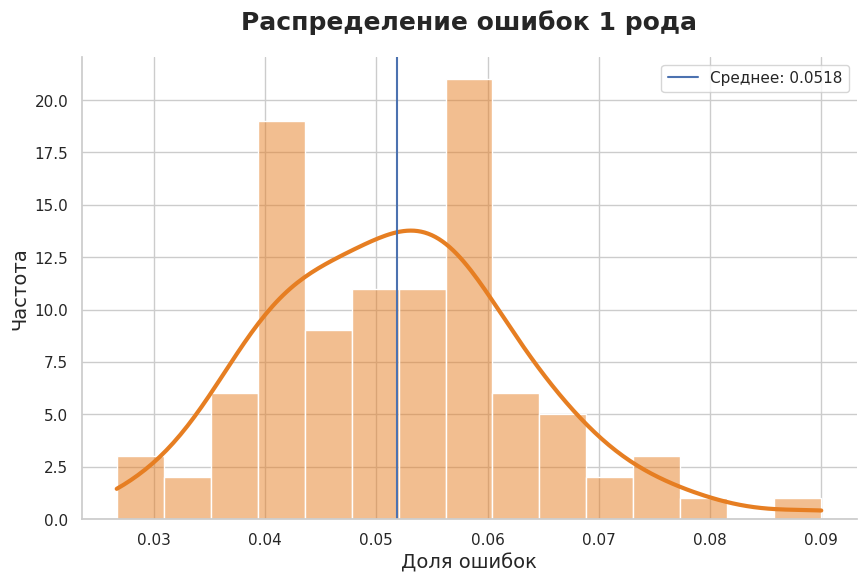

In [ ]:
plot_errors_distribution(type_one_error_df, error_type='1')

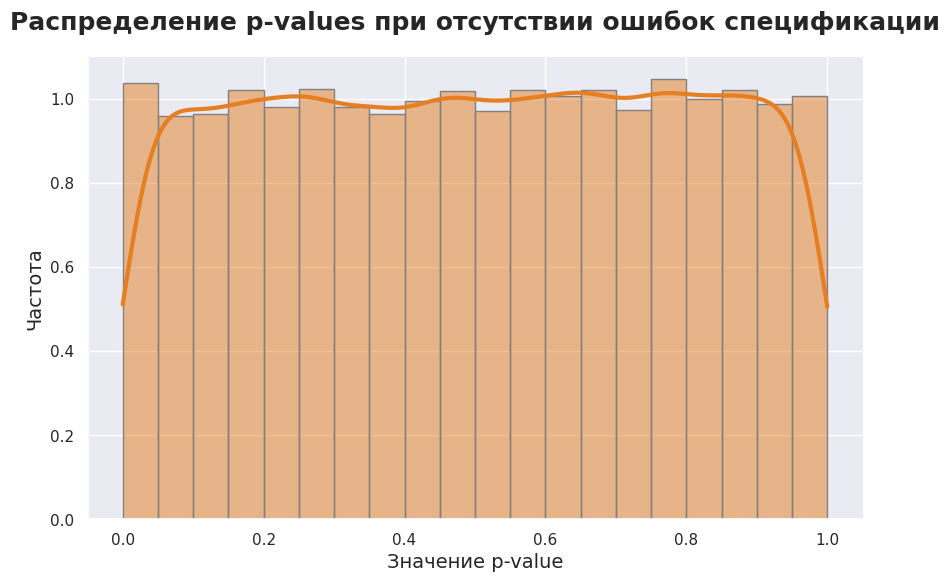

In [ ]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6), dpi=100)

ax = sns.histplot(
  type_one_error_df.explode('p-values')['p-values'].astype(float),
  bins=20,
  stat='density',
  kde=True,
  color='#e67e22',
  edgecolor='gray',
  line_kws={'linewidth': 3}
)

plt.title(f"Распределение p-values при отсутствии ошибок спецификации", fontsize=18, pad=20, fontweight='bold')
plt.xlabel("Значение p-value", fontsize=14)
plt.ylabel("Частота", fontsize=14)

sns.despine()

plt.show()

#### Дополнительно исследуем, какие факторы симуляции оказывают влияние на долю ошибок первого рода. Для этих целей используем тепловую карту и дерево решений.

In [ ]:
columns_to_drop = ['Тип ошибки','p-values', 'Количество взаимодействий', 'Корреляция существ. регрессора', 'Влияние существ. регрессора', 'Количество реальных нелин. предикторов']
corr = type_one_error_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

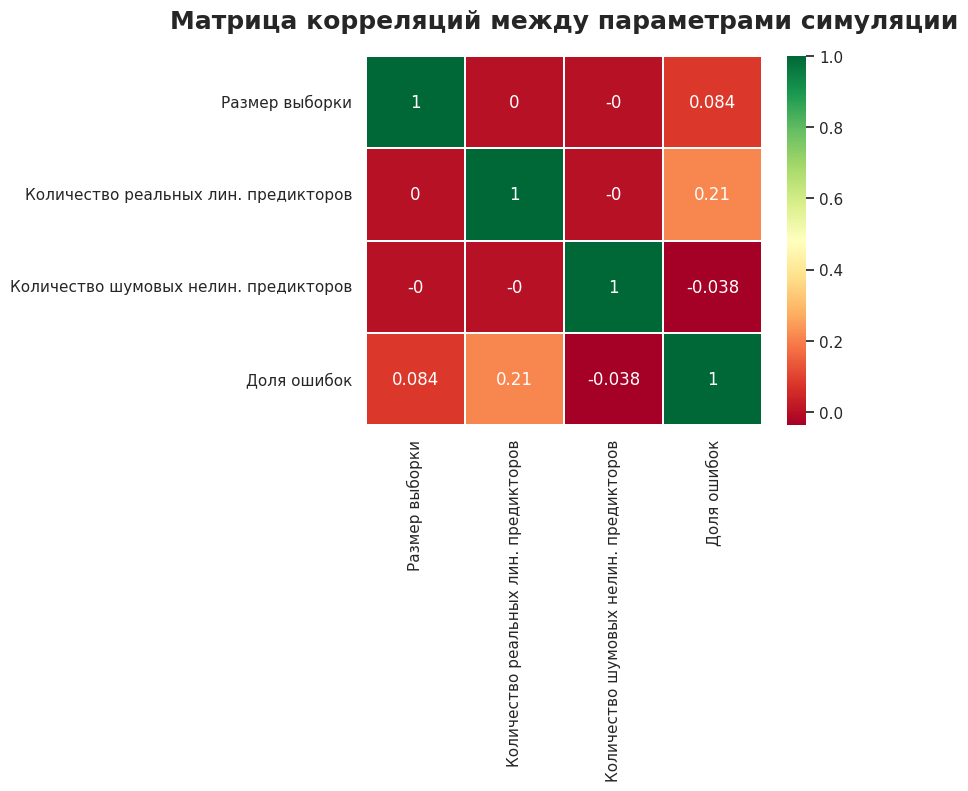

In [ ]:
sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')
plt.show()

#### Вывод: корреляций между долей ошибок 1 рода и параметрами симуляции практически нет

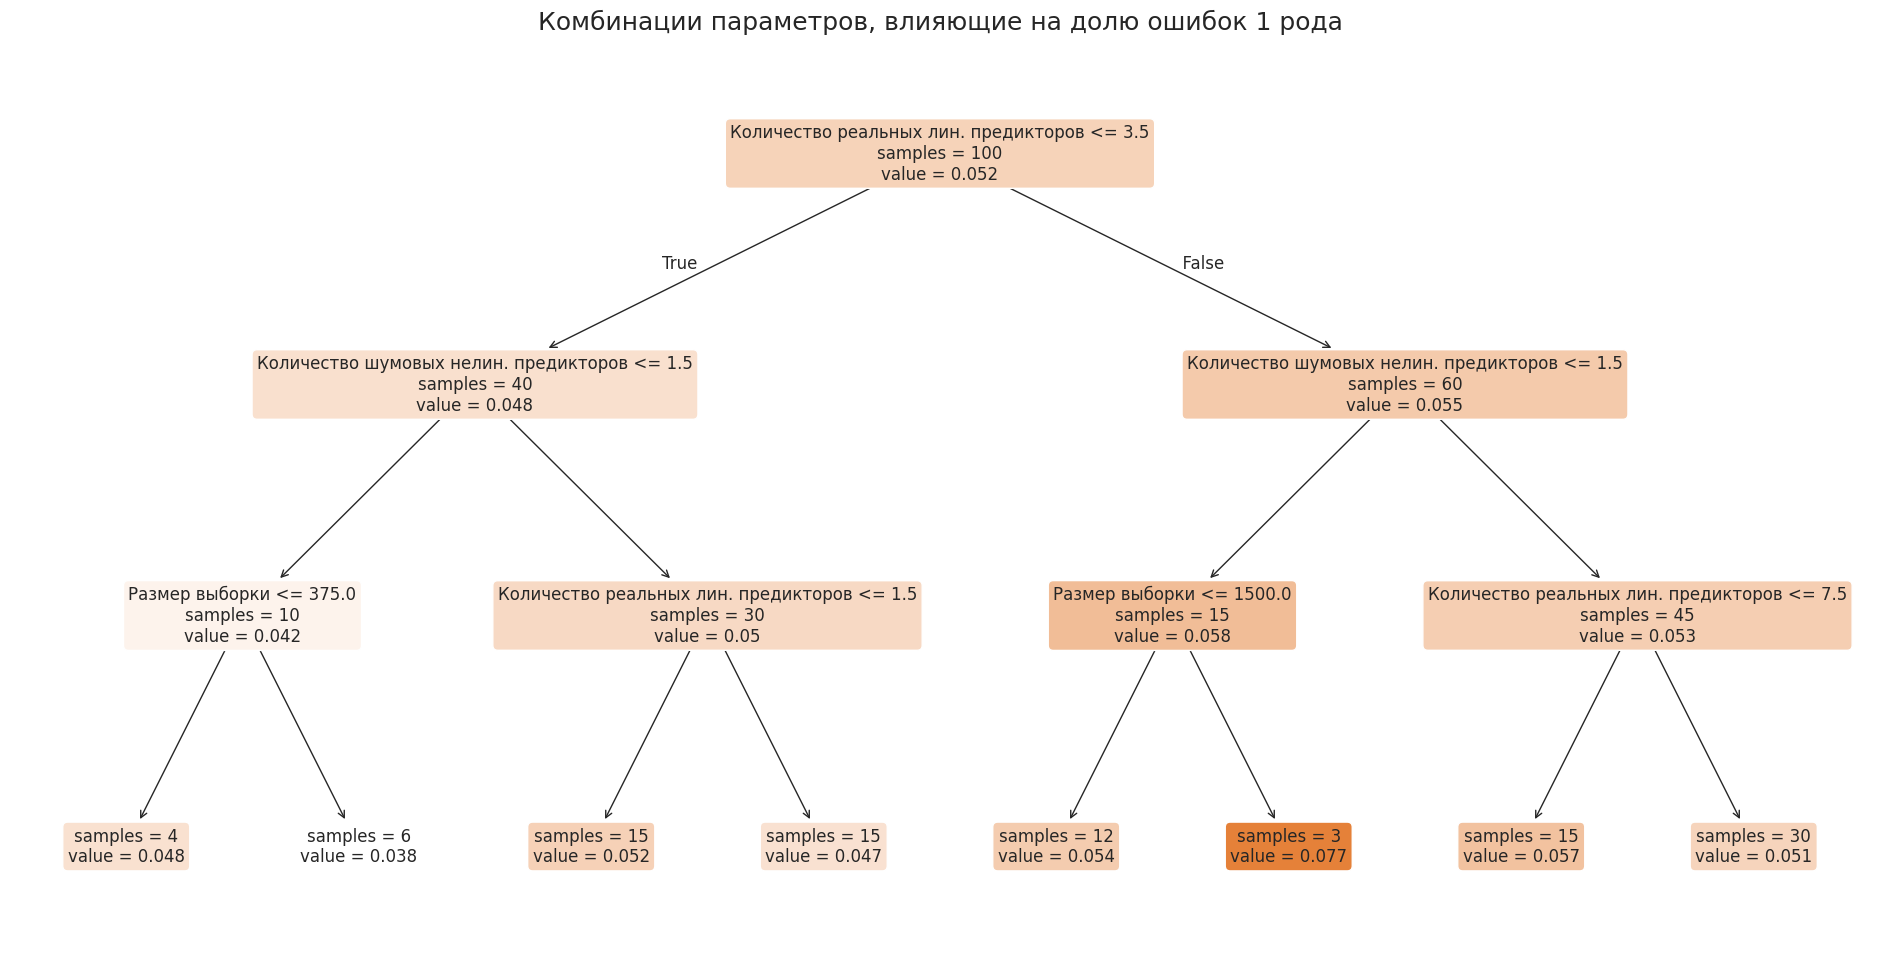

In [ ]:
plot_decision_tree_thresholds(type_one_error_df, error_type='1')

#### Вывод: комбинаций факторов симуляции, значительно влияющих на долю ошибок 1 рода, нет.

In [ ]:
type_one_error_df.to_csv('type_one_error_df.csv')

## **Общий вывод**

RESET-тест в реальных симуляциях показал свойства точного критерия, имеющего вероятность совершения ошибок 1 рода примерно равную заданному уровню значимости. Распределение p-values равномерное. Ни один из факторов симуляции не оказывает существенного влияния на долю ошибок.

# Исследование ошибки 2 рода

## При наличии нелинейных предикторов

In [ ]:
# Пробегаем симуляции только с нелинейными предикторами

sample_sizes = [100, 250, 500, 1000]
true_non_linear_terms_amounts = [1, 2, 3, 4]
feature_amounts = [1, 2, 5, 10]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0]
significant_regressor_effects = [0]
interactions = [0]

plant_seed()

second_type_errors_map_non_linear_terms = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

In [ ]:
type_two_error_non_linear_terms_df = pd.DataFrame.from_dict(second_type_errors_map_non_linear_terms, orient='index').set_index('Номер симуляции')

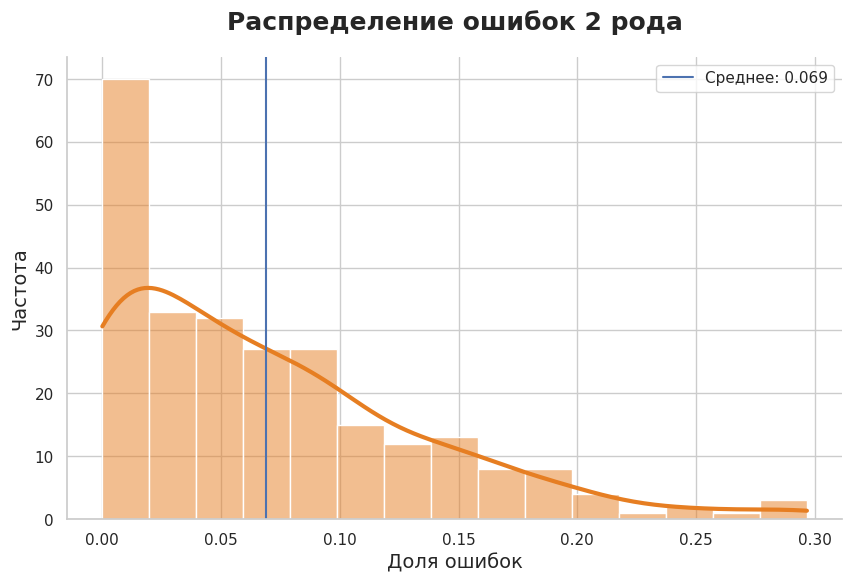

In [ ]:
plot_errors_distribution(type_two_error_non_linear_terms_df, error_type='2')

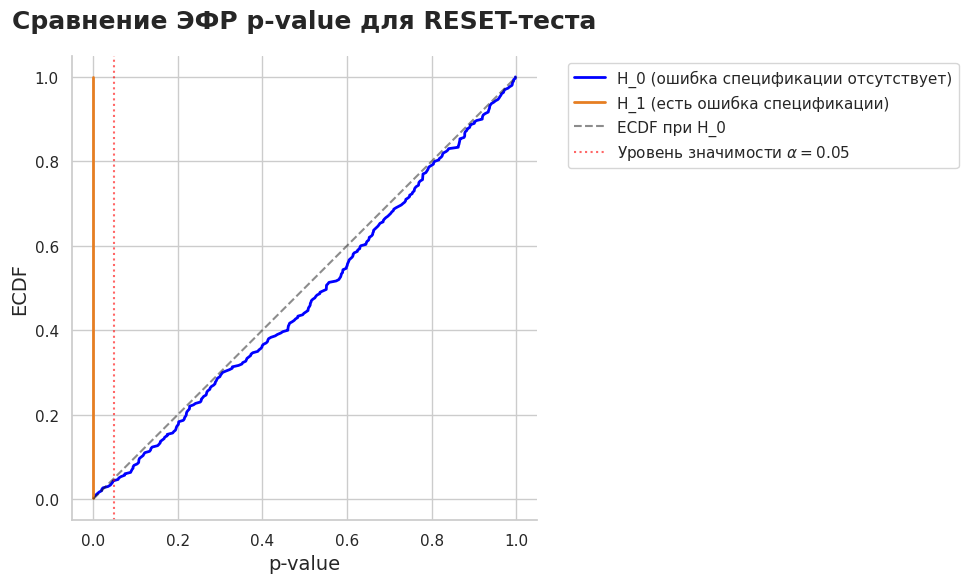

In [ ]:
p_values_h0, p_values_h1 = find_p_values_equal_params(first_type_errors_map, second_type_errors_map_non_linear_terms, **{'Количество реальных нелин. предикторов': 3})

plot_ecdf(p_values_h0, p_values_h1)

#### Вывод: средняя мощность RESET-теста равна приблизительно 0.93 при наличии нелинейных предикторов

In [ ]:
columns_to_drop = ['Тип ошибки','p-values', 'Количество взаимодействий', 'Корреляция существ. регрессора', 'Влияние существ. регрессора']

corr = type_two_error_non_linear_terms_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

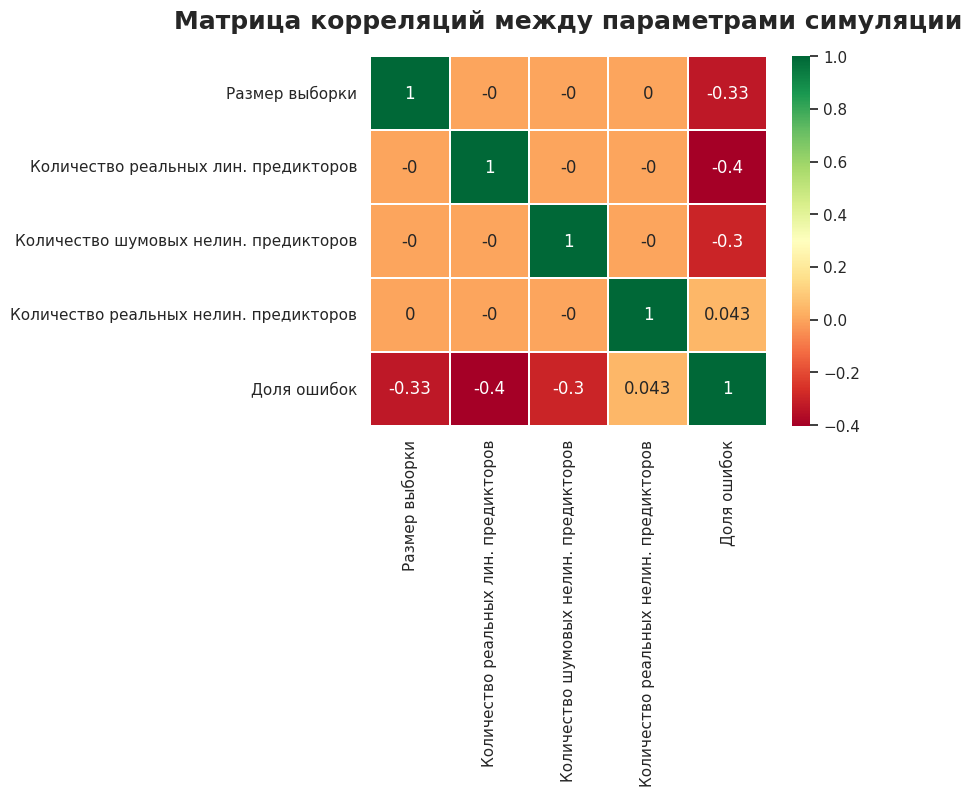

In [ ]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

#### Вывод: чем больше выборка и чем больше исходных признаков, тем ниже доля ошибок 2 рода и выше мощность

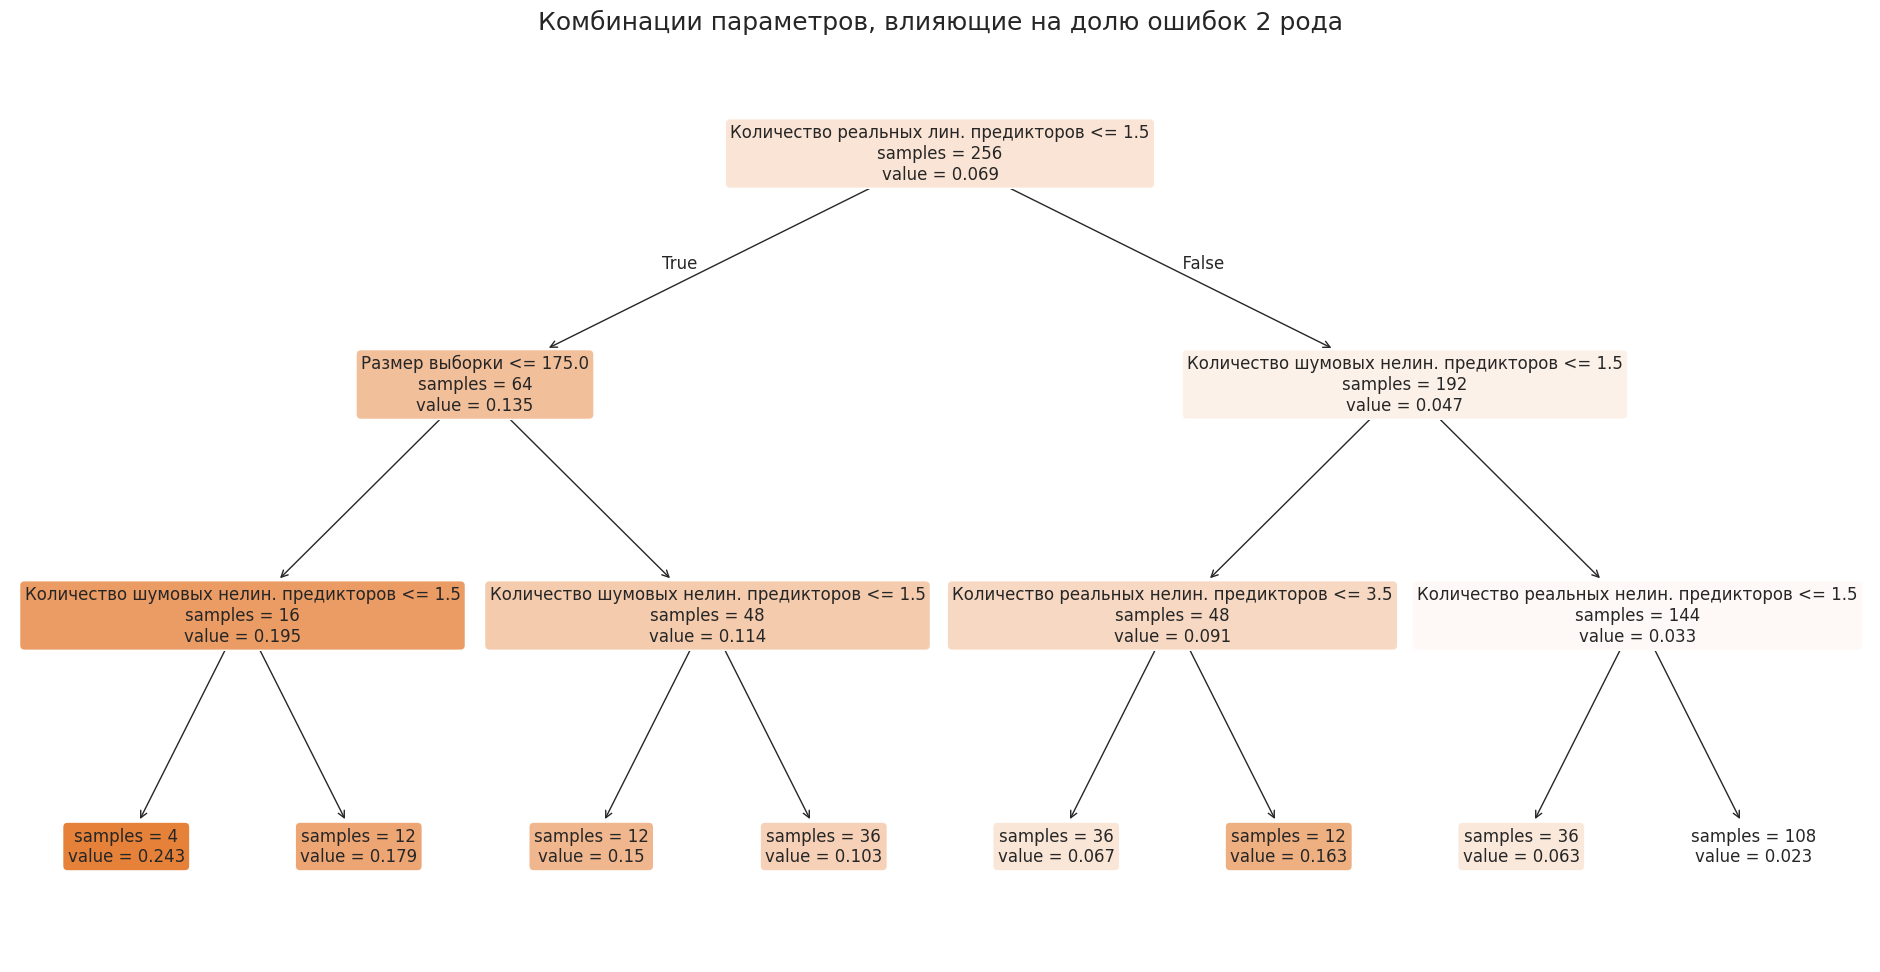

In [ ]:
plot_decision_tree_thresholds(type_two_error_non_linear_terms_df, error_type='2')

#### Вывод: комбинация маленькой выборки, небольшого количества искусственно созданных нелинейных предикторов и исходных признаков предсказывает повышенную долю ошибок 2 рода. И напротив, когда количество реальных нелинейных предикторов выше, доля ошибок падает.

In [ ]:
type_two_error_non_linear_terms_df.to_csv('type_two_error_non_linear_terms_df.csv')

### **Общий вывод**

Симуляции с ошибкой спецификации при наличии нелинейности показали, что RESET-тест имеет высокую мощность и практически не пропускает наличие нелинейности, за исключением симуляций с небольшой выборкой и маленьким количеством добавляемых нелинейных предикторов.

## При наличии взаимодействий

In [ ]:
# Пробегаем симуляции только с взаимодействиями

sample_sizes = [100, 250, 500, 1000]
true_non_linear_terms_amounts = [0]
feature_amounts = [3, 4, 5, 10]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0]
significant_regressor_effects = [0]
interactions = [1, 2, 3]

plant_seed()

second_type_errors_map_interactions = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

In [ ]:
type_two_error_interactions_df = pd.DataFrame.from_dict(second_type_errors_map_interactions, orient='index').set_index('Номер симуляции')

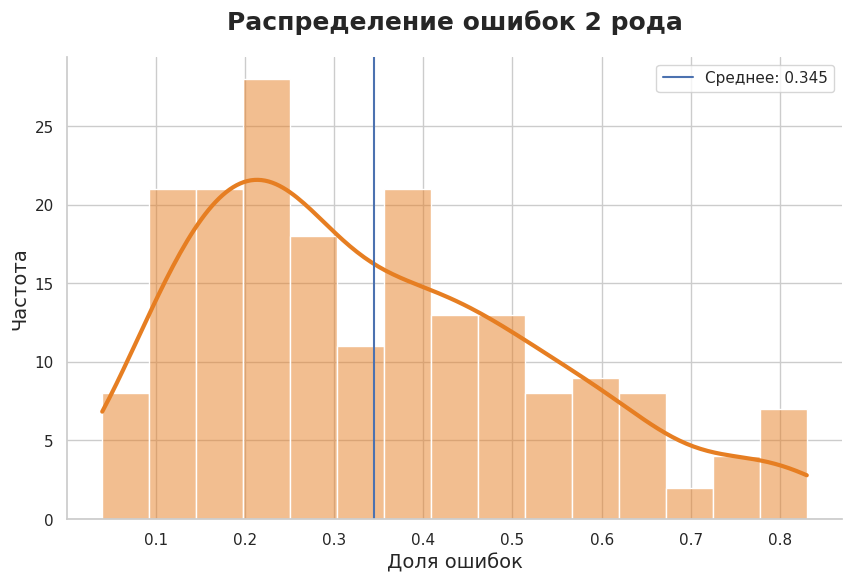

In [ ]:
plot_errors_distribution(type_two_error_interactions_df, error_type='2')

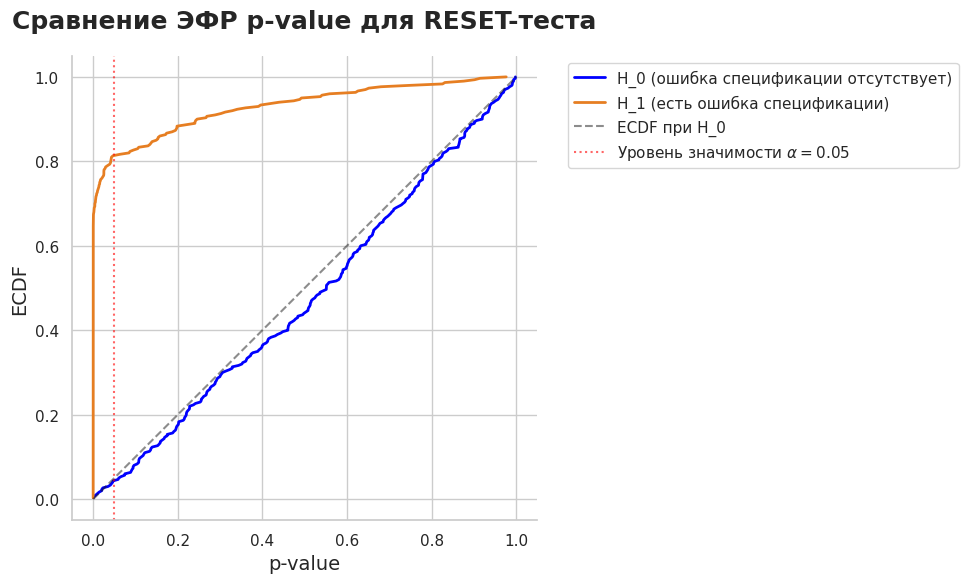

In [ ]:
p_values_h0, p_values_h1 = find_p_values_equal_params(first_type_errors_map, second_type_errors_map_interactions, **{'Количество взаимодействий': 2})

plot_ecdf(p_values_h0, p_values_h1)

#### Вывод: при наличии взаимодействий признаков RESET-тест имеет значительно повышенную долю ошибок 2 рода

In [ ]:
columns_to_drop = ['Тип ошибки', 'p-values', 'Количество реальных нелин. предикторов', 'Корреляция существ. регрессора', 'Влияние существ. регрессора']

corr = type_two_error_interactions_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

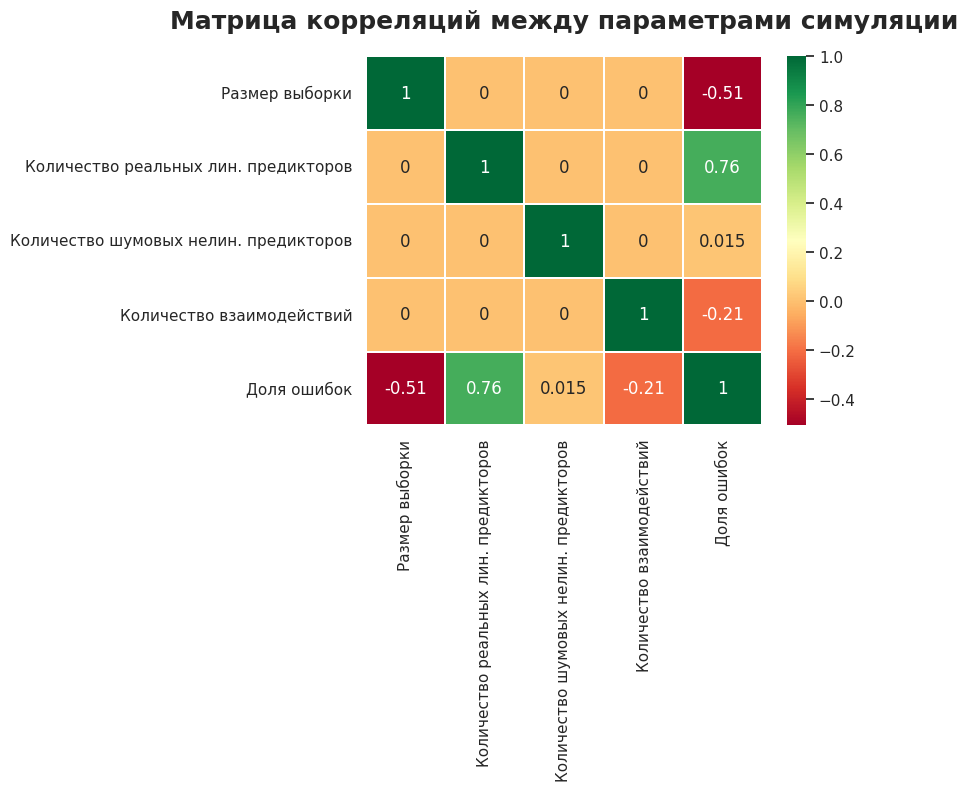

In [ ]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

#### Вывод: при наличии взаимодействий признаков чем больше исходное количество предикторов, тем выше доля ошибок 2 рода, и в то же время, чем больше выборка, тем ниже доля ошибок. Количество взаимодействий при этом имеет слабую связь с долей ошибок - предположительно, чем больше взаимодействий, тем ниже вероятность ошибки 2 рода.

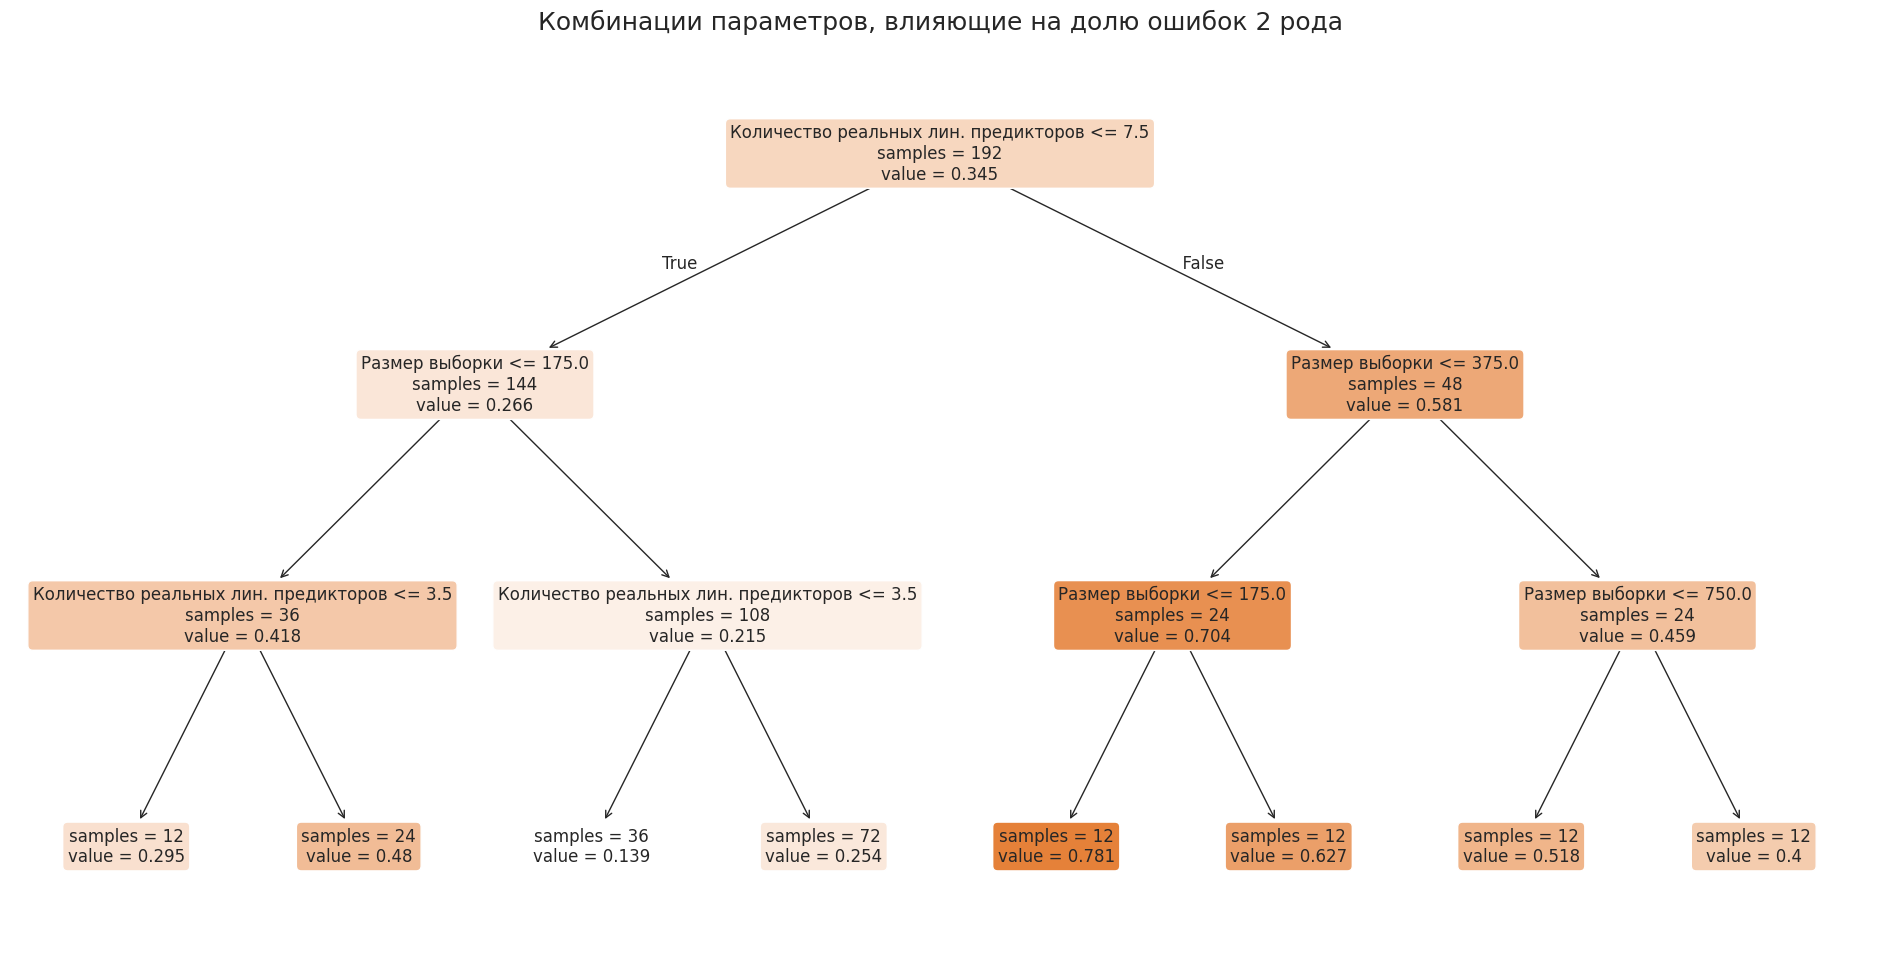

In [ ]:
plot_decision_tree_thresholds(type_two_error_interactions_df, error_type='2')

#### Вывод: комбинация маленькой выборки и большого числа исходных признаков радикально повышает вероятность ошибок 2 рода. И наоборот, меньше всего ошибок 2 рода происходило в симуляция с бОльшей выборкой и малым числом исходных признаков.

In [ ]:
type_two_error_interactions_df.to_csv('type_two_error_interactions_df.csv')

### **Общий вывод**
RESET-тест значительно чаще допускает ошибку 2 рода в условиях присутствия взаимодействий между признаками, чем в условиях присутствия нелинейных предикторов, особенно в симуляциях с небольшими выборками и малым числом признаков.

## При наличии существенных регрессоров

In [ ]:
# Пробегаем симуляции только с значительными регрессорами

sample_sizes = [100, 500, 1000]
true_non_linear_terms_amounts = [0]
feature_amounts = [3, 4, 5, 10]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0.05, 0.5, 0.9]
significant_regressor_effects = [1, 2, 5]
interactions = [0]

plant_seed()

second_type_errors_sig_regr = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

In [ ]:
type_two_error_sig_regr_df = pd.DataFrame.from_dict(second_type_errors_sig_regr, orient='index').set_index('Номер симуляции')

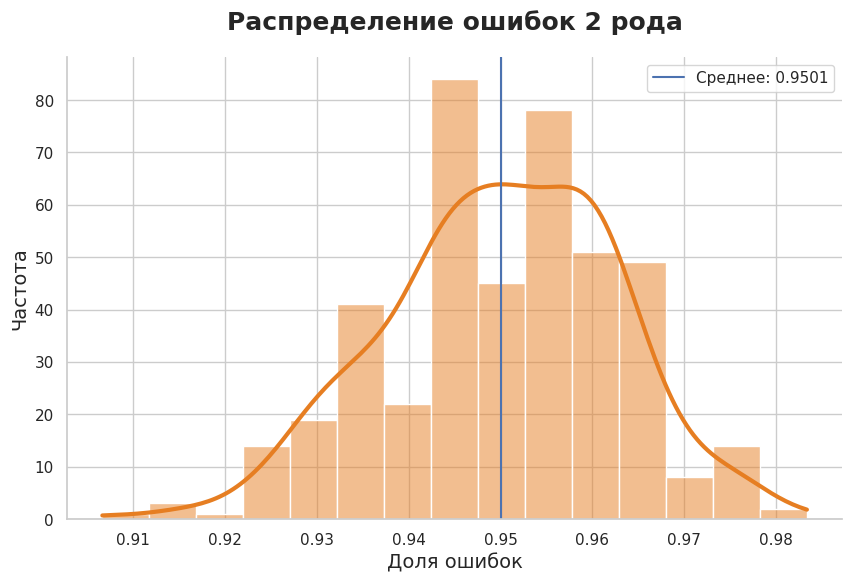

In [ ]:
plot_errors_distribution(type_two_error_sig_regr_df, error_type='2')

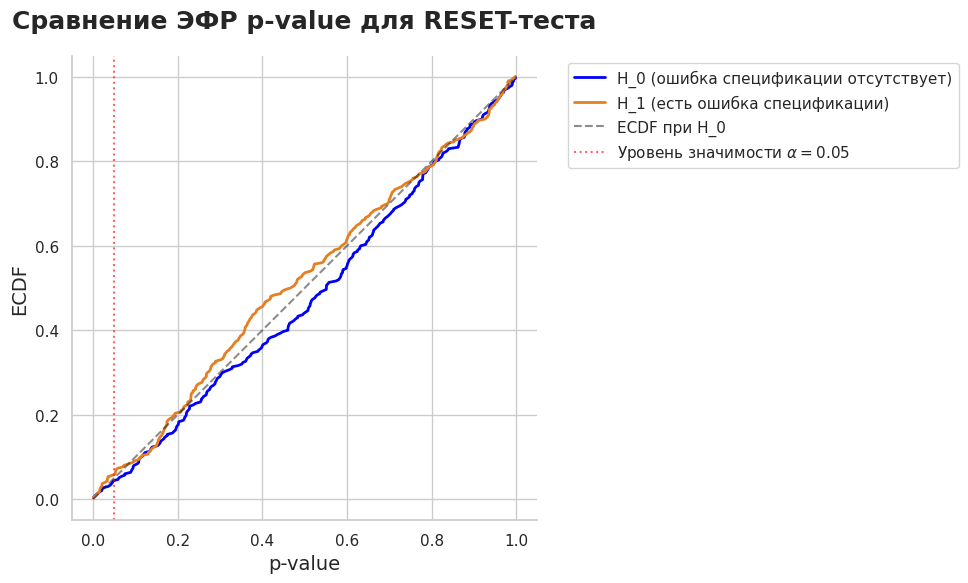

In [ ]:
p_values_h0, p_values_h1 = find_p_values_equal_params(first_type_errors_map, second_type_errors_sig_regr,
                                                      **{'Корреляция существ. регрессора': 0.9, 'Влияние существ. регрессора': 2})

plot_ecdf(p_values_h0, p_values_h1)

#### Вывод: RESET-тест имеет крайне низкую мощность для обнаружения скрытых существенных регрессоров.

In [ ]:
columns_to_drop = ['Тип ошибки', 'p-values', 'Количество реальных нелин. предикторов', 'Количество взаимодействий']

corr = type_two_error_sig_regr_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

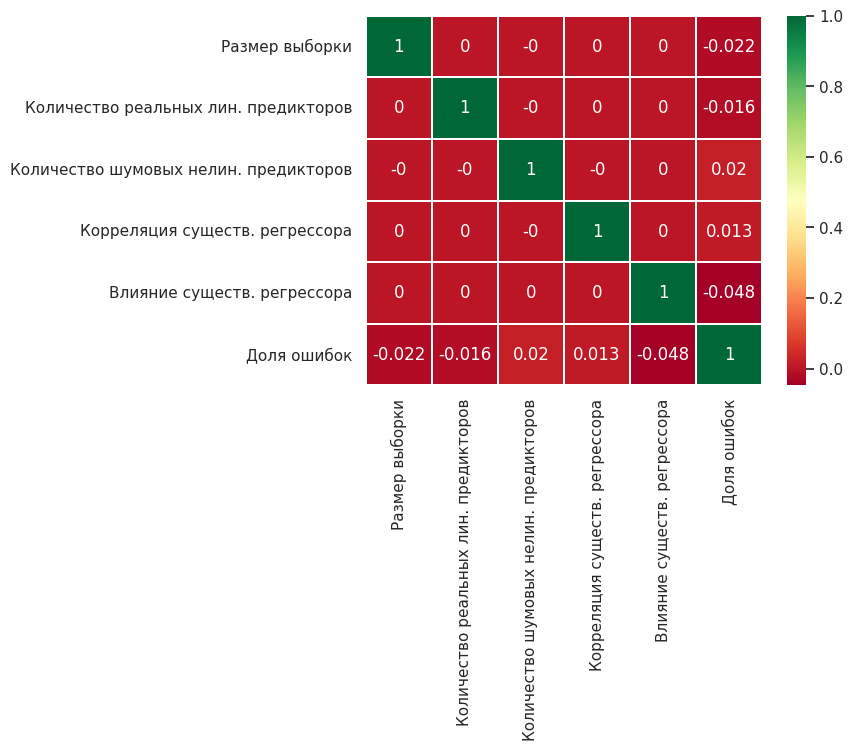

In [ ]:
sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

#### Вывод: видимых корреляций между факторами симуляции и долей ошибок 2 рода нет.

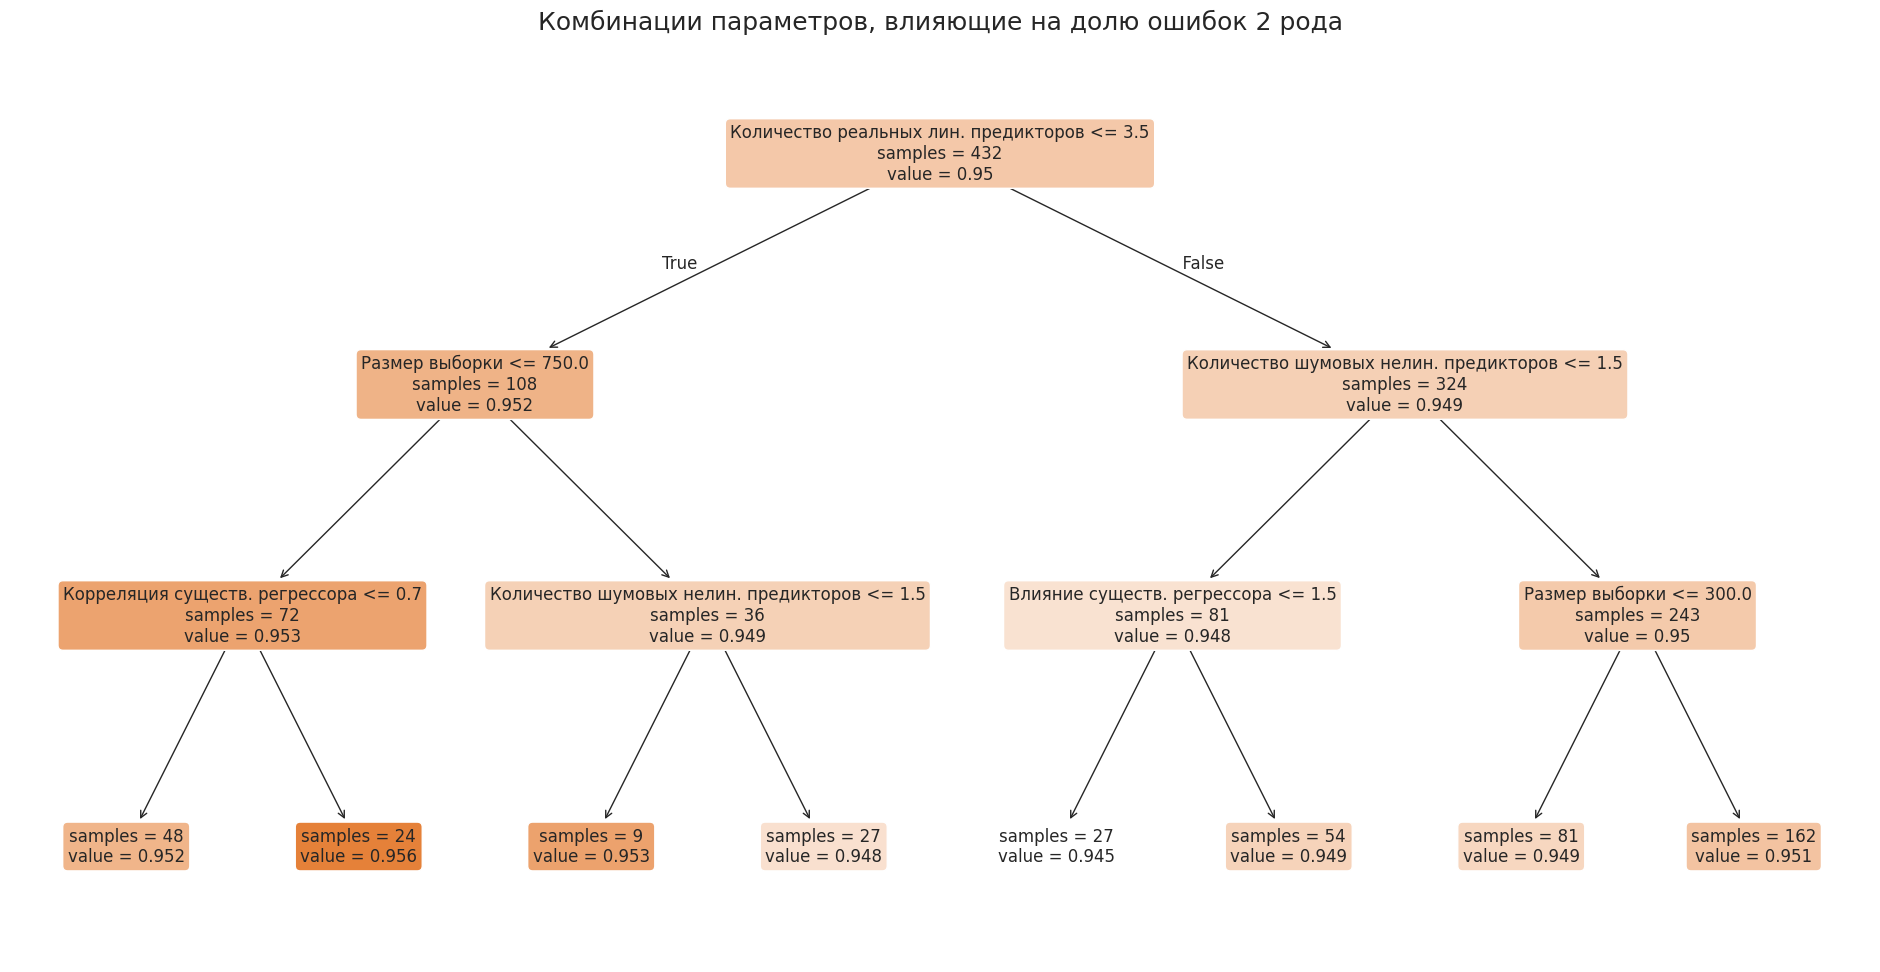

In [ ]:
plot_decision_tree_thresholds(type_two_error_sig_regr_df, error_type='2')

#### Вывод: не было обнаружено комбинаций, значительно меняющих вероятность ошибок 2 рода

In [ ]:
type_two_error_sig_regr_df.to_csv('type_two_error_sig_regr_df.csv')

### **Общий вывод**

Симуляции показали, что предположение RESET-теста о том, что любая ошибка спецификации порождает нелинейность, делает его склонным к совершению ошибок 2 рода при наличии линейной ошибки спецификации (линейный существенный регрессор)

## При комбинации всех трех типов искажений

In [ ]:
sample_sizes = [500, 1000]
true_non_linear_terms_amounts = [0, 1, 2, 5]
feature_amounts = [5, 10]
added_features_amounts = [2, 3, 4]
significant_regressor_correlations = [0, 0.5, 0.9]
significant_regressor_effects = [0, 2, 5]
interactions = [0, 1, 2]

plant_seed()

second_type_errors_all_factors = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

In [ ]:
type_two_error_all_factors_df = pd.DataFrame.from_dict(second_type_errors_all_factors, orient='index').set_index('Номер симуляции')

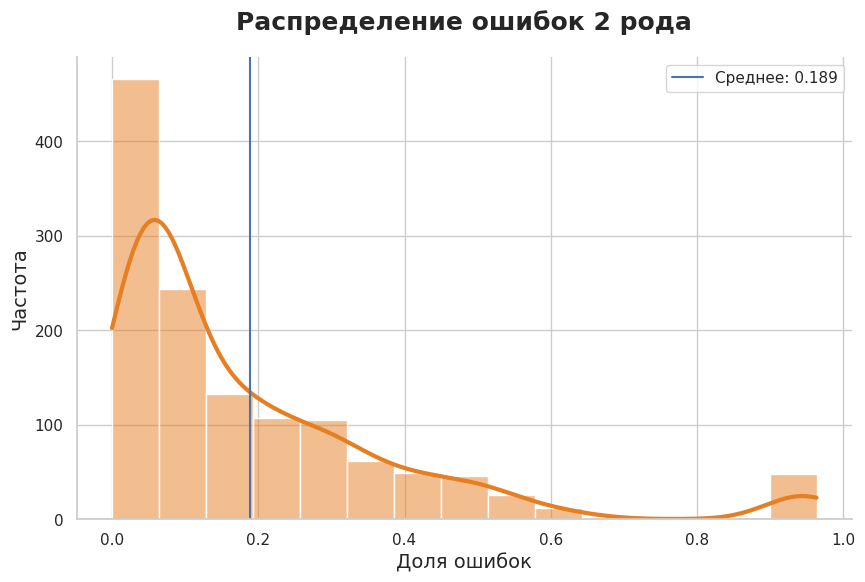

In [ ]:
plot_errors_distribution(type_two_error_all_factors_df, error_type='2')

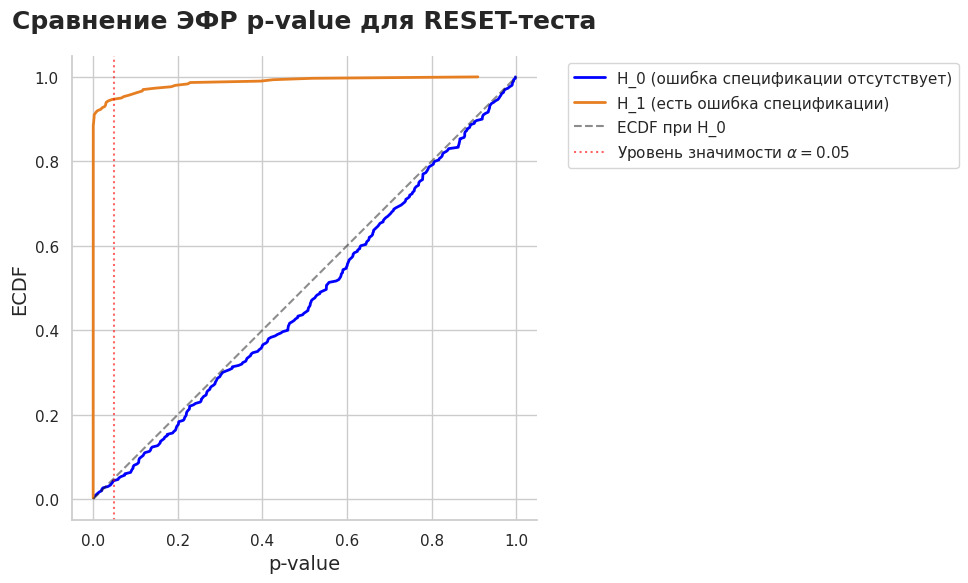

In [ ]:
p_values_h0, p_values_h1 = find_p_values_equal_params(first_type_errors_map, second_type_errors_all_factors,
                                                      **{'Корреляция существ. регрессора': 0.5, 'Влияние существ. регрессора': 2, 'Количество взаимодействий': 1,
                                                         'Количество реальных нелин. предикторов': 2})

plot_ecdf(p_values_h0, p_values_h1)

#### Вывод: в общем случае, при наличии разного рода ошибок спецификации линейной регрессии (нелинейность, взаимодействия, существенный регрессор) RESET-тест имеет адекватную среднюю мощность - примерно 0.81

In [ ]:
columns_to_drop = ['Тип ошибки', 'p-values']

corr = type_two_error_all_factors_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

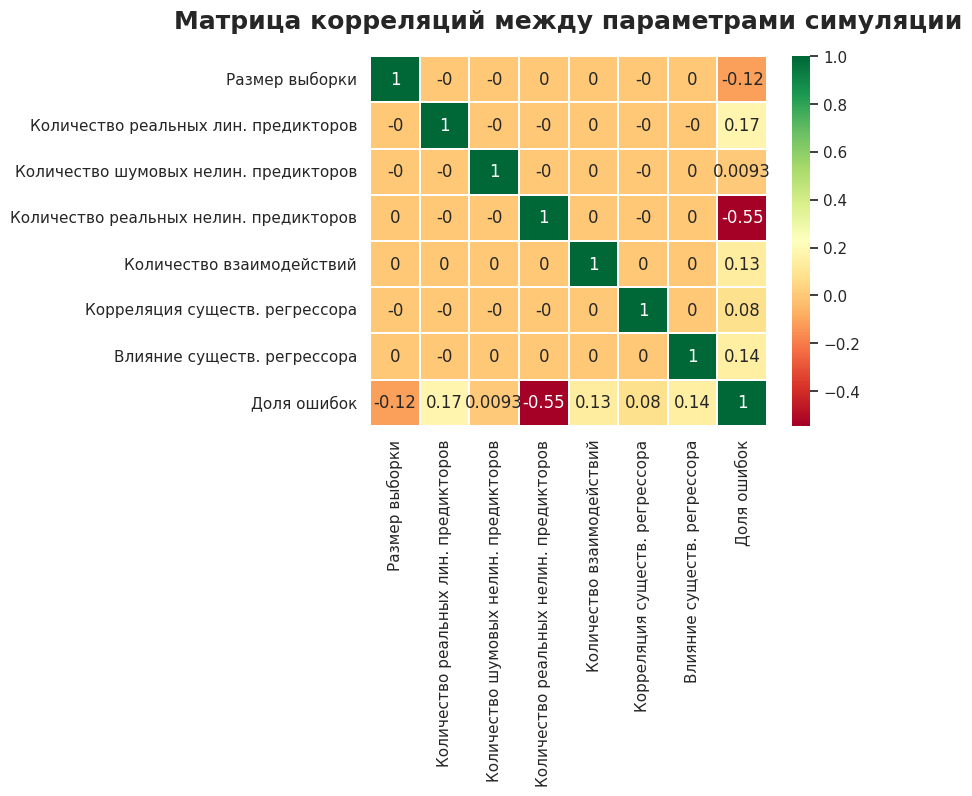

In [ ]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

#### Вывод: единственный фактор, имеющий значительную корреляцию с долей ошибок второго рода - количество нелинейных предикторов. Чем больше нелинейности, тем выше вероятность правильно отвергнуть альтернативную гипотезу, даже если есть другие "неблагоприятные" факторы для RESET-теста (например, линейная ошибка спецификации)

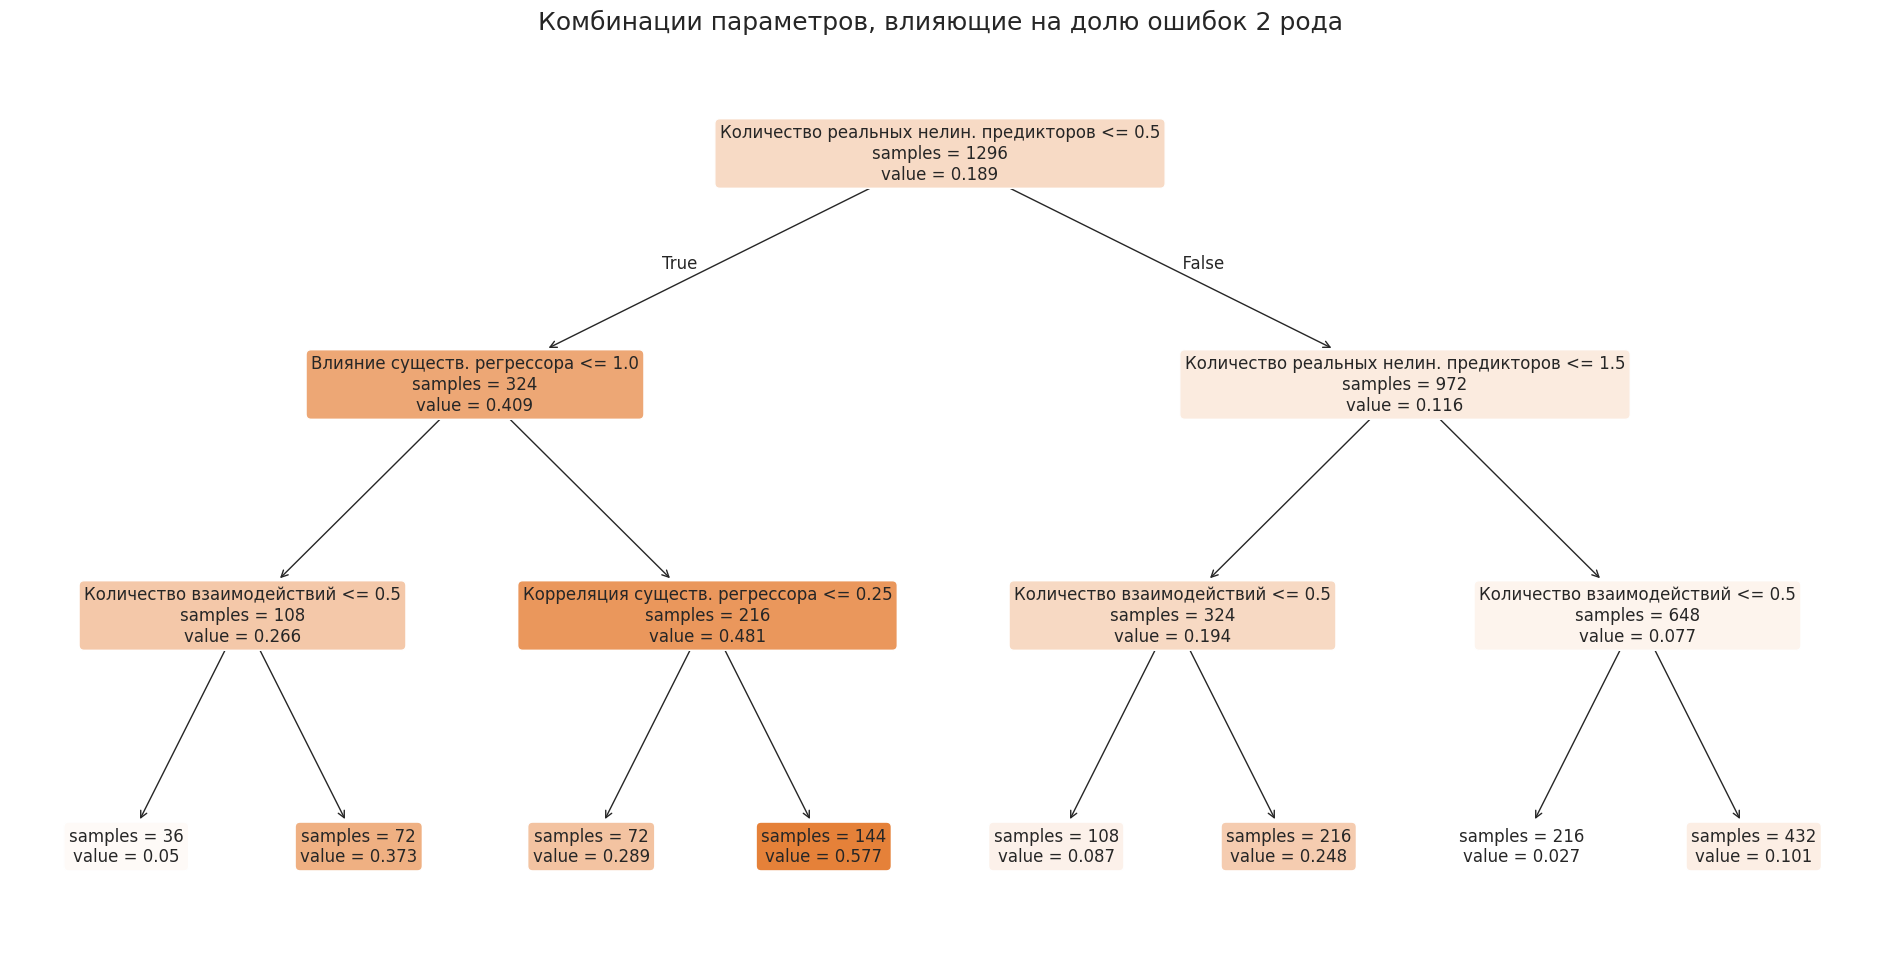

In [ ]:
plot_decision_tree_thresholds(type_two_error_all_factors_df, error_type='2')

#### Вывод: самый неблагоприятный сценарий для RESET-теста - отсутствие нелинейных предикторов, высокое влияние и высокая корреляция существенного регрессора. И напротив, вероятность ошибки 2 рода наименьшая, когда есть нелинейность и низкое количество взаимодействий.

In [ ]:
type_two_error_all_factors_df.to_csv('type_two_error_all_factors_df.csv')

### **Общий вывод**: RESET-тест показывает высокую мощность в условиях нелинейности, среднюю мощность в условиях взаимодействий, низкую мощность при наличии существенных регрессоров, и сбалансированную мощность при комбинации всех трех типов ошибок спецификации.

# Применение на реальных данных

#### Исследуем недавно выпущенный датасет о  популярных GitHub репозиториях: https://www.kaggle.com/datasets/elvisbui/top-github-repositories-2026

In [ ]:
import kagglehub

path = kagglehub.dataset_download("elvisbui/top-github-repositories-2026")

print("Path to dataset files:", path)

100%|██████████| 74.9k/74.9k [00:00<00:00, 467kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elvisbui/top-github-repositories-2026/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/elvisbui/top-github-repositories-2026/versions/1

top_github_repos_2026.csv


In [ ]:
df = pd.read_csv(f"{path}/top_github_repos_2026.csv")

In [ ]:
df.head()

,name,description,language,stars,forks,open_issues,watchers,created_at,updated_at,topics,license,is_fork,has_wiki,archived,size_kb,default_branch,homepage
0,codecrafters-io/build-your-own-x,Master programming by recreating your favorite...,Markdown,487662,45893,462,487662,2018-05-09,2026-04-09,awesome-list|free|programming|tutorial-code|tu...,NaN,False,False,False,1201,master,https://codecrafters.io
1,sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,NaN,453320,34056,59,453320,2014-07-11,2026-04-09,awesome|awesome-list|lists|resources|unicorns,CC0-1.0,False,False,False,1535,main,NaN
2,freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,442235,44192,200,442235,2014-12-24,2026-04-09,careers|certification|community|curriculum|d3|...,BSD-3-Clause,False,False,False,559313,main,https://contribute.freecodecamp.org
3,public-apis/public-apis,A collective list of free APIs,Python,420283,45730,1216,420283,2016-03-20,2026-04-09,api|apis|dataset|development|free|list|lists|o...,MIT,False,False,False,4962,master,https://APILayer.com/?utm_source=Github&utm_me...
4,EbookFoundation/free-programming-books,:books: Freely available programming books,Python,385209,66095,79,385209,2013-10-11,2026-04-09,books|education|hacktoberfest|list|resource,CC-BY-4.0,False,False,False,21200,main,https://ebookfoundation.github.io/free-program...


In [ ]:
(df['watchers']-df['stars']).value_counts() # по сути это дублирующиеся колонки, поэтому нужно будет их удалить.

,count
0,627


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627 entries, 0 to 626
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            627 non-null    object
 1   description     625 non-null    object
 2   language        609 non-null    object
 3   stars           627 non-null    int64 
 4   forks           627 non-null    int64 
 5   open_issues     627 non-null    int64 
 6   watchers        627 non-null    int64 
 7   created_at      627 non-null    object
 8   updated_at      627 non-null    object
 9   topics          538 non-null    object
 10  license         593 non-null    object
 11  is_fork         627 non-null    bool  
 12  has_wiki        627 non-null    bool  
 13  archived        627 non-null    bool  
 14  size_kb         627 non-null    int64 
 15  default_branch  627 non-null    object
 16  homepage        503 non-null    object
dtypes: bool(3), int64(5), object(9)
memory usage: 70.5+ KB

In [ ]:
df['is_fork'].unique() # всего одно значение признака, отбрасываем его вместе с некоторыми другими как неинформативный

array([False])

In [ ]:
df['language'].value_counts()

,count
language,
Python,108
TypeScript,107
JavaScript,93
Go,91
Java,90
Rust,90
Shell,7
HTML,5
C++,4


In [ ]:
df.drop(columns=['watchers', 'homepage','name', 'default_branch', 'license', 'description', 'topics', 'created_at', 'updated_at', 'is_fork', 'language'], inplace=True)

Также поскольку у нас всего 18 наблюдений с NaN по языку, для простоты избавимся от них тоже

In [ ]:
df.dropna(inplace=True)

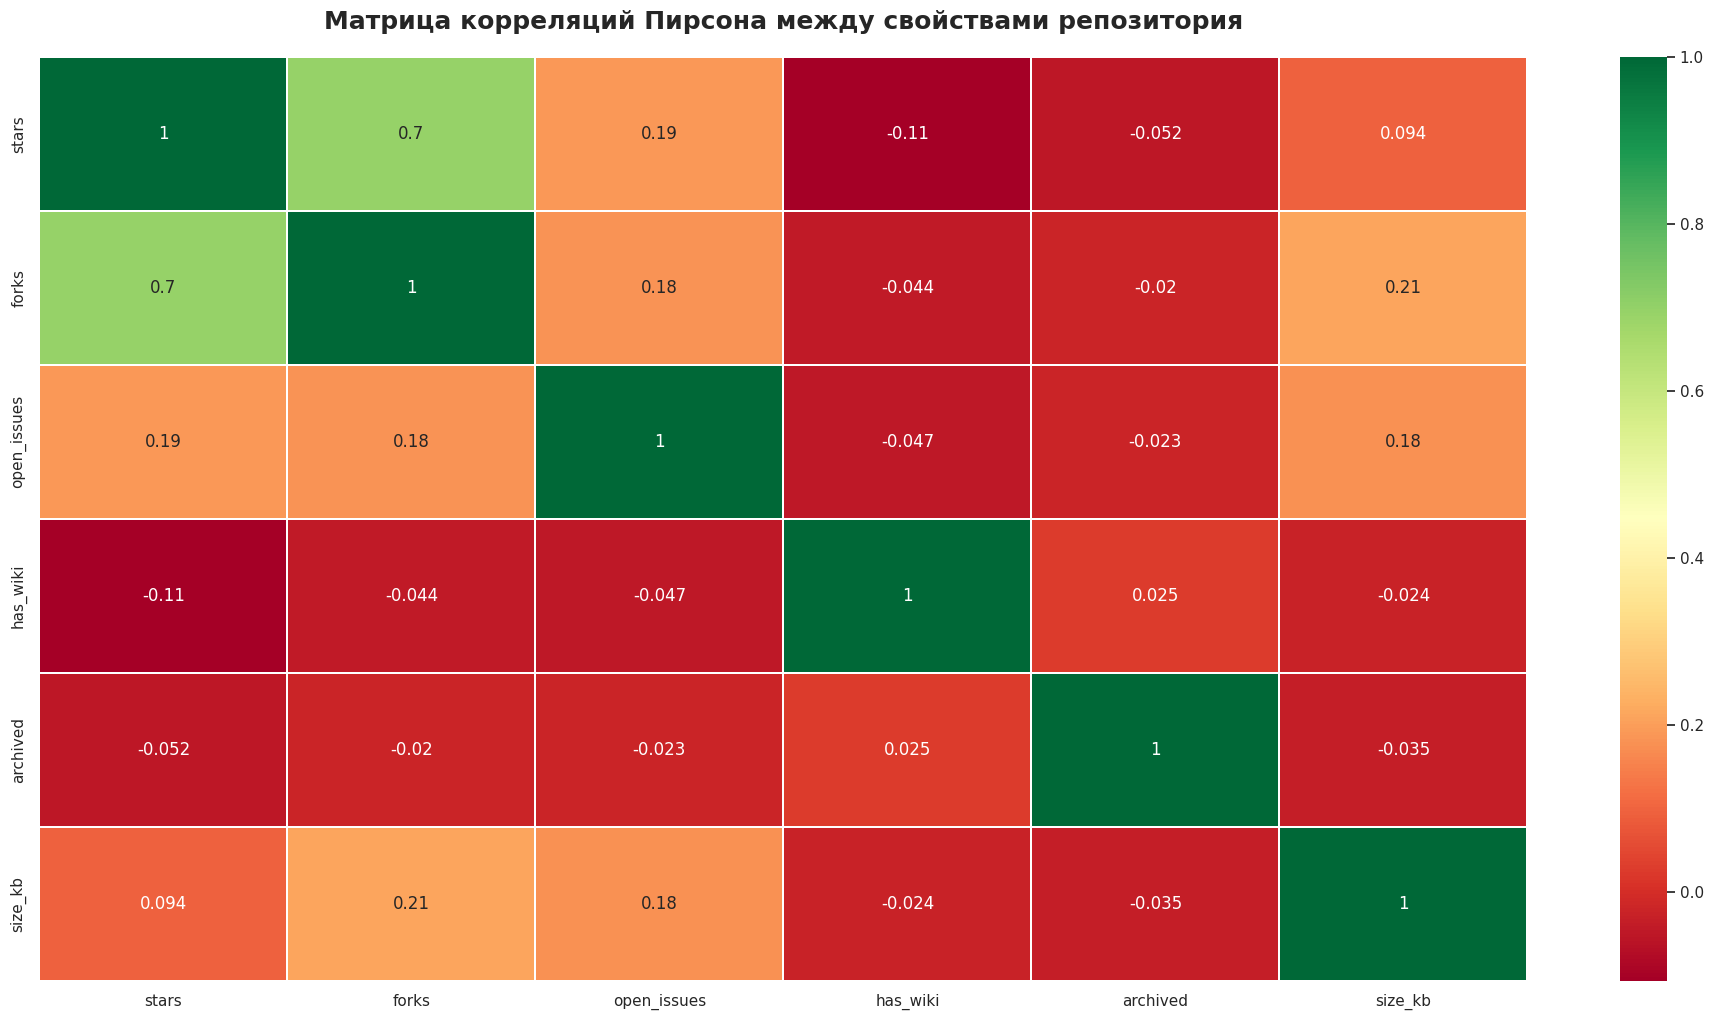

In [ ]:
pearson_corr = df.corr()

plt.figure(figsize=(24, 12), dpi=100)
sns.heatmap(pearson_corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.title(f"Матрица корреляций Пирсона между свойствами репозитория", fontsize=18, pad=20, fontweight='bold')
plt.show()

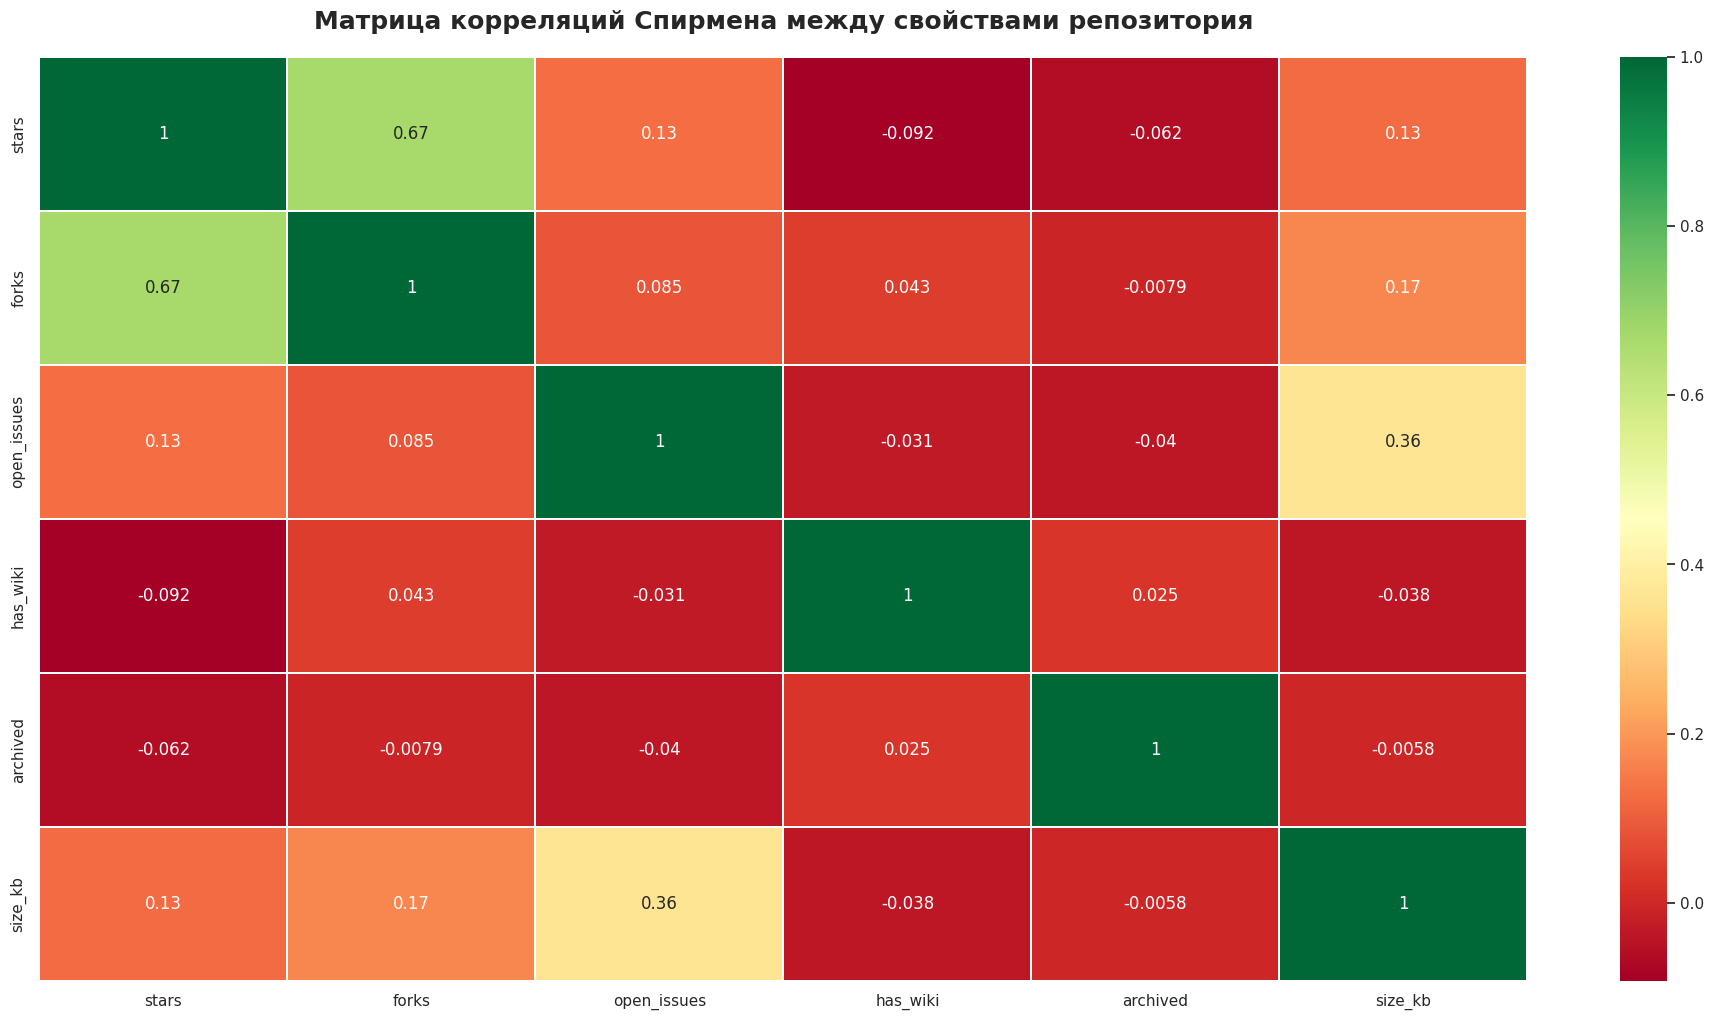

In [ ]:
spearman_corr = df.corr(method='spearman')

plt.figure(figsize=(24, 12), dpi=100)
sns.heatmap(spearman_corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.title(f"Матрица корреляций Спирмена между свойствами репозитория", fontsize=18, pad=20, fontweight='bold')
plt.show()

### Для того, чтобы обнаружить потенциальные нелинейные (но монотонные) связи, вычтем матрицу корреляций Пирсона из матрицы корреляций Спирмена.

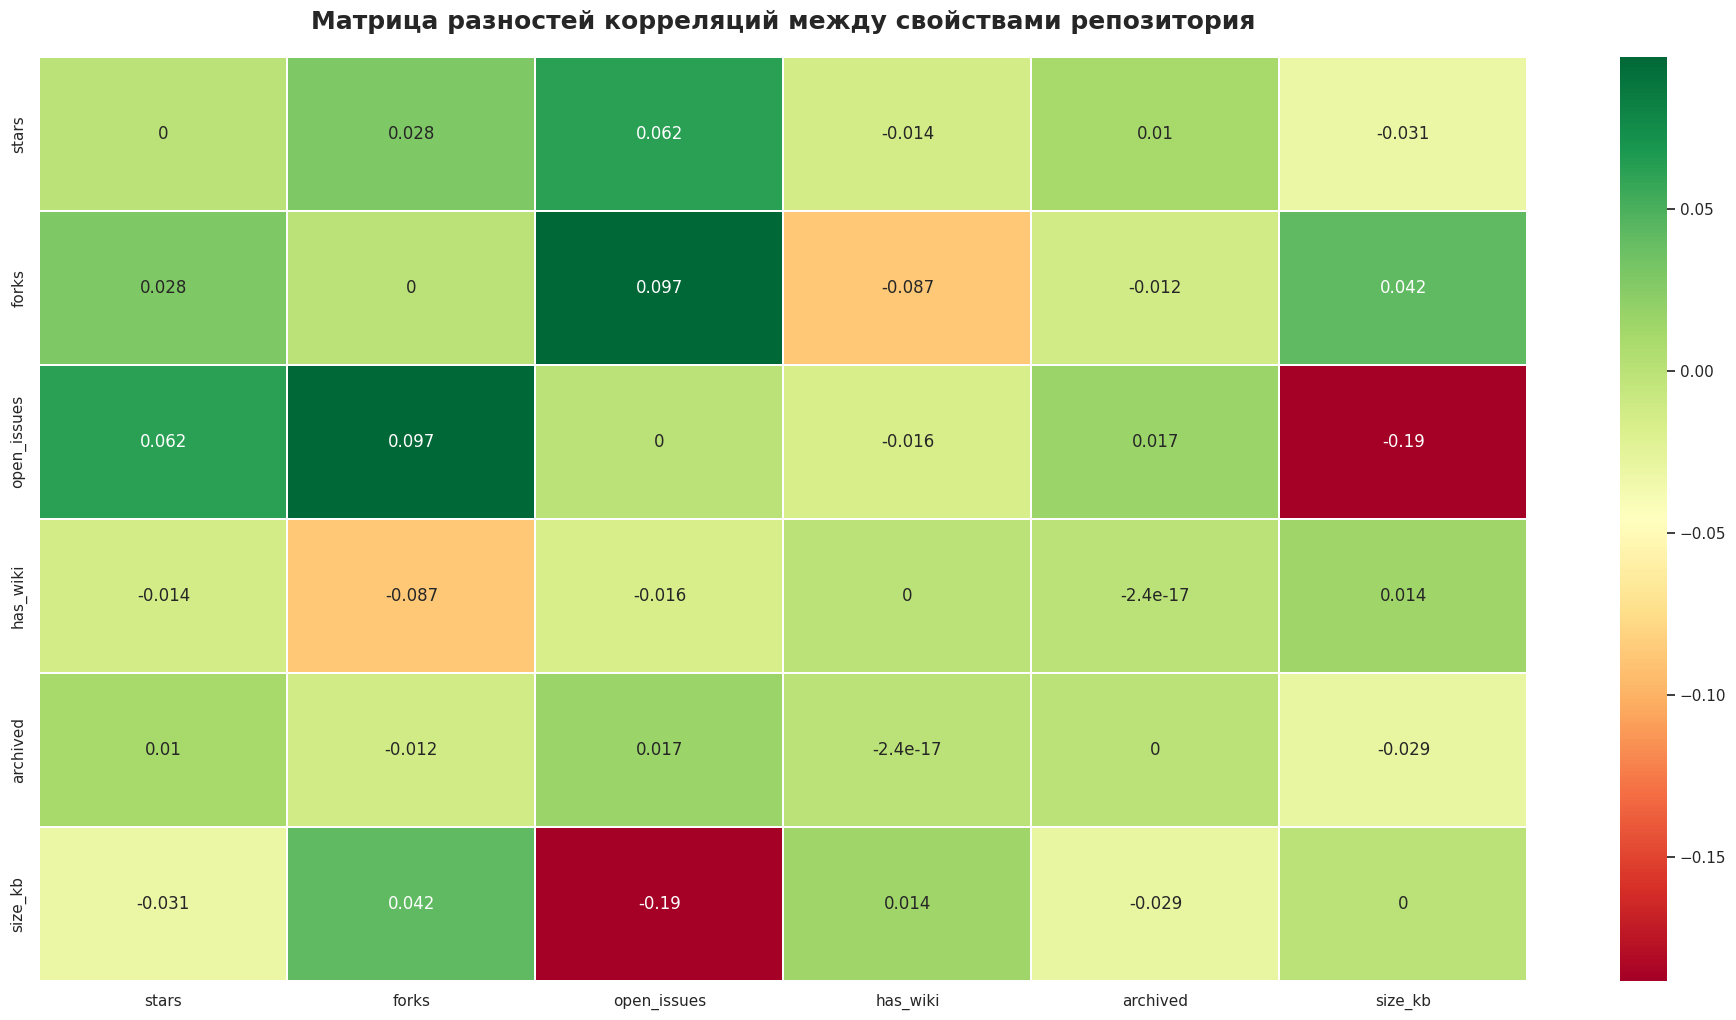

In [ ]:
diff_corr = pearson_corr - spearman_corr
plt.figure(figsize=(24, 12), dpi=100)
sns.heatmap(diff_corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.title(f"Матрица разностей корреляций между свойствами репозитория", fontsize=18, pad=20, fontweight='bold')
plt.show()

### Такой анализ не показал интересных результатов, поэтому выполним графический EDA.

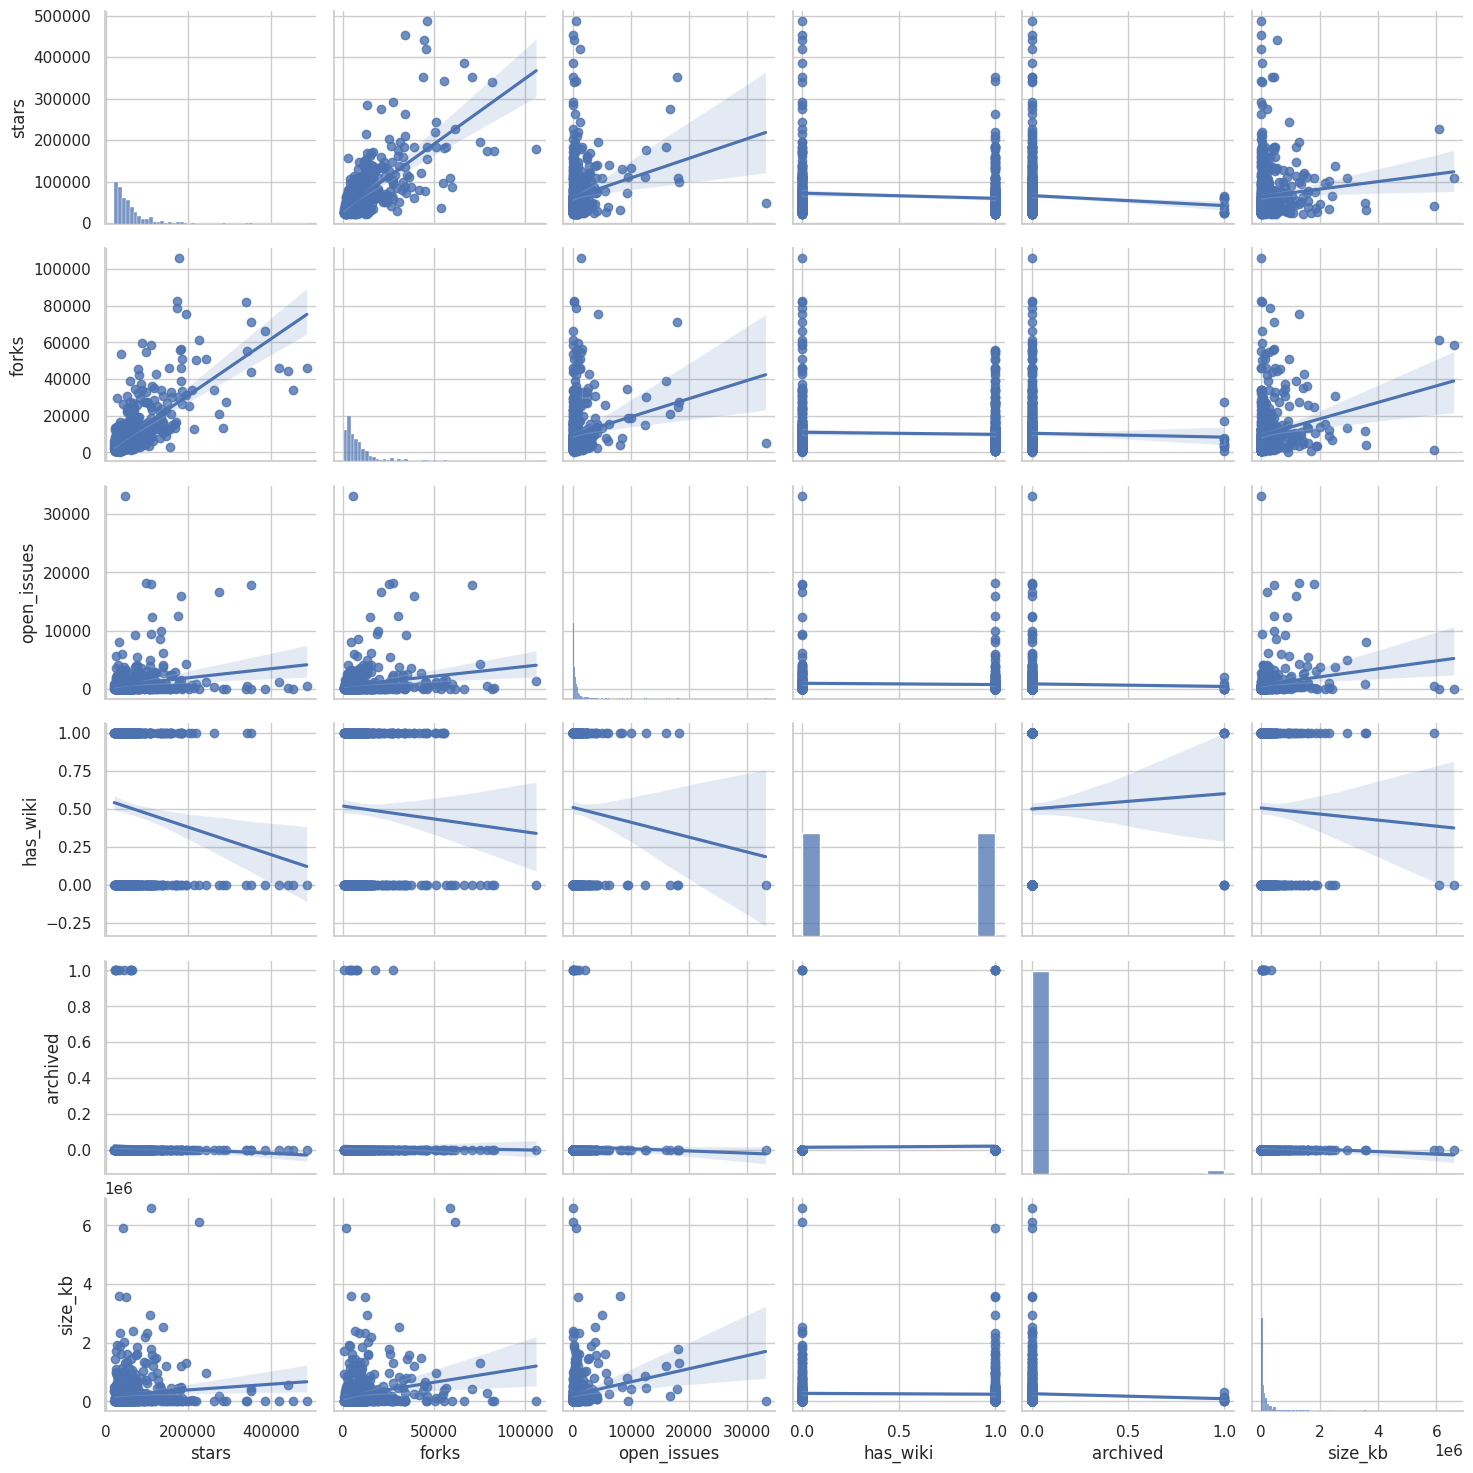

In [ ]:
sns.pairplot(df, kind='reg')
plt.show()

### Все числовые признаки распределены экспоненциально.

Прологарифмируем признаки, а также добавим квадратичный и кубический члены к уравнению регрессии, чтобы проверить ошибку спецификации линейной регрессии

In [ ]:
X = df.drop(columns=['stars'])
exp_features = ['open_issues', 'size_kb', 'forks']
X[exp_features] = np.log1p(X[exp_features])

y = np.log1p(df['stars'].values.reshape(-1, 1))

ss1, ss2, df1, df2 = compare_lin_regs(x=X, y=y, added_features_amount=2)

In [ ]:
p = compute_f_significance(ss1, ss2, df1, df2)
print(f'p-value: {p}')

p-value: 2.0719292549700788e-11


Вывод: с большой долей уверенности можно сказать, что присутствует нелинейная ошибка спецификации для линейной регрессии на этом датасете.

In [ ]:
!jupyter nbconvert --to html "/content/reset_test_study.ipynb"